# Master Seminar on Econometrics
## Using Google Search Data to Nowcast German Unemployment

Name : Alexander Unger
Matrikelnummer : 6946672


In [1]:
import pandas as pd

# indeed data
indeed_w1 = pd.read_csv("./new_data/Indeed_w1.csv", sep=",", skiprows=1)
indeed_w2 = pd.read_csv("./new_data/Indeed_w2.csv", sep=",", skiprows=1)
indeed_w3 = pd.read_csv("./new_data/Indeed_w3.csv", sep=",", skiprows=1)

# stepstone data
stepstone_w1 = pd.read_csv("./new_data/Stepstone_w1.csv", sep=",", skiprows=1)
stepstone_w2 = pd.read_csv("./new_data/Stepstone_w2.csv", sep=",", skiprows=1)
stepstone_w3 = pd.read_csv("./new_data/Stepstone_w3.csv", sep=",", skiprows=1)

# bewerbung data 
Bewerbung_w1 = pd.read_csv("./new_data/Bewerbung_w1.csv", sep=",", skiprows=1)
Bewerbung_w2 = pd.read_csv("./new_data/Bewerbung_w2.csv", sep=",", skiprows=1)
Bewerbung_w3 = pd.read_csv("./new_data/Bewerbung_w3.csv", sep=",", skiprows=1)

# arbeitsamt data
arbeitsamt_w1 = pd.read_csv("./new_data/Arbeitsamt_w1.csv", sep=",", skiprows=1)
arbeitsamt_w2 = pd.read_csv("./new_data/Arbeitsamt_w2.csv", sep=",", skiprows=1)
arbeitsamt_w3 = pd.read_csv("./new_data/Arbeitsamt_w3.csv", sep=",", skiprows=1)

# jobbörse data 
jobbörse_w1 = pd.read_csv("./new_data/Jobbörse_w1.csv", sep=",", skiprows=1)
jobbörse_w2 = pd.read_csv("./new_data/Jobbörse_w2.csv", sep=",", skiprows=1)
jobbörse_w3 = pd.read_csv("./new_data/Jobbörse_w3.csv", sep=",", skiprows=1)

## Define the columns for all
indeed_w1.columns = ["Date", "indeed"]
indeed_w2.columns = ["Date", "indeed"]
indeed_w3.columns = ["Date", "indeed"]

stepstone_w1.columns = ["Date", "stepstone"]
stepstone_w2.columns = ["Date", "stepstone"]
stepstone_w3.columns = ["Date", "stepstone"]

Bewerbung_w1.columns = ["Date","bewerbung"]
Bewerbung_w2.columns = ["Date","bewerbung"]
Bewerbung_w3.columns = ["Date","bewerbung"]

arbeitsamt_w1.columns = ["Date", "arbeitsamt"]
arbeitsamt_w2.columns = ["Date", "arbeitsamt"]
arbeitsamt_w3.columns = ["Date", "arbeitsamt"]

jobbörse_w1.columns = ["Date", "jobbörse"]
jobbörse_w2.columns = ["Date", "jobbörse"]
jobbörse_w3.columns = ["Date", "jobbörse"]


for df in [indeed_w1,indeed_w2,indeed_w3, stepstone_w1, stepstone_w2, stepstone_w3, Bewerbung_w1,Bewerbung_w2,Bewerbung_w3, arbeitsamt_w1,arbeitsamt_w2,arbeitsamt_w3, jobbörse_w1, jobbörse_w2, jobbörse_w3]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    df[df.columns[1]] = pd.to_numeric(df[df.columns[1]], errors="coerce")


- **Google Trends data must be downloaded in multiple overlapping windows** to obtain a continuous weekly series over long horizons (e.g., 2011–2023). Each download window yields its own 0–100 normalization, so I load them separately first, then stitch later. 
- The GT CSV export format typically includes a **header/meta row**, and the data columns can arrive as strings. Enforcing a clean schema early prevents downstream failures in stitching, aggregation, and stationarity transformations.
- A consistent column layout (`Date`, `<keyword>`) makes it straightforward to write generic functions that work across all keywords and windows.


## 1. Stitch overlapping Google Trends windows into a single weekly series (2011–2023)


### Inputs / Outputs
**Inputs**
- Three Google Trends downloads per keyword (`w1`, `w2`, `w3`) that overlap in time.
  - Each input DataFrame contains `Date` and a keyword-specific value column (e.g., `indeed`).

**Outputs**
- One stitched DataFrame per keyword:
  - `indeed`, `stepstone`, `bewerbung`, `arbeitsamt`, `jobboerse`
- Each output has:
  - Weekly observations (strict 7-day spacing)
  - A consistent scale across the full sample
  - Trimmed to the analysis window: `START` … `END_WEEK`

In [2]:
import numpy as np

# Here I select the sunday timestep
START = pd.Timestamp("2011-05-01")      
END_WEEK = pd.Timestamp("2023-01-29")   
END_MONTH = pd.Timestamp("2023-01-31")  

def _prep(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = df[["Date", value_col]].copy()
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce").dt.tz_localize(None)
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = out.dropna(subset=["Date", value_col]).set_index("Date").sort_index()
    return out

def _median_ratio(a: pd.Series, b: pd.Series) -> float:
    idx = a.index.intersection(b.index)
    x, y = a.loc[idx], b.loc[idx]
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    return float(np.median((x[mask] / y[mask]).values)) if mask.sum() else 1.0

def stitch_three(w1: pd.DataFrame, w2: pd.DataFrame, w3: pd.DataFrame,
                 value_col: str, final_name: str | None = None) -> pd.DataFrame:
    W1 = _prep(w1, value_col)
    W2 = _prep(w2, value_col)
    W3 = _prep(w3, value_col)

    # rescaling W2
    s21 = _median_ratio(W1[value_col], W2[value_col])
    W2r = W2.copy()
    W2r[value_col] = W2r[value_col] * s21

    # rescaling W3
    s32 = _median_ratio(W2r[value_col], W3[value_col])
    W3r = W3.copy()
    W3r[value_col] = W3r[value_col] * s32

    # concatenate without duplicate dates 
    out = pd.concat([
        W1,
        W2r.loc[~W2r.index.isin(W1.index)],
        W3r.loc[~W3r.index.isin(W1.index.union(W2r.index))]
    ]).sort_index()


    out = out.loc[(out.index >= START) & (out.index <= END_WEEK)].copy()

    name = final_name or value_col
    out = out.rename(columns={value_col: name}).reset_index().rename(columns={"index": "Date"})
    return out


indeed     = stitch_three(indeed_w1, indeed_w2, indeed_w3, "indeed")
stepstone  = stitch_three(stepstone_w1, stepstone_w2, stepstone_w3, "stepstone")
bewerbung  = stitch_three(Bewerbung_w1, Bewerbung_w2, Bewerbung_w3, "bewerbung")
arbeitsamt = stitch_three(arbeitsamt_w1, arbeitsamt_w2, arbeitsamt_w3, "arbeitsamt")
jobboerse  = stitch_three(jobbörse_w1, jobbörse_w2, jobbörse_w3, "jobbörse")

# my sanity
for name, d in [("indeed", indeed), ("stepstone", stepstone), ("jobbörse", jobboerse), ("arbeitsamt", arbeitsamt), ("bewerbung", bewerbung)]:
    if not (d["Date"].diff().dropna().dt.days == 7).all():
        raise ValueError(f"{name}: not strictly weekly (7-day steps)")
    

# creating one big weekly dataset
df_week = (stepstone.merge(indeed,     on="Date", how="inner")
                   .merge(jobboerse,   on="Date", how="inner")
                   .merge(arbeitsamt, on="Date", how="inner")
                   .merge(bewerbung,  on="Date", how="inner"))


In [3]:
df_week.head()


,Date,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
0,2011-05-01,49.0,14.0,75.0,86.0,63.0
1,2011-05-08,50.0,14.0,80.0,84.0,68.0
2,2011-05-15,52.0,14.0,80.0,87.0,73.0
3,2011-05-22,52.0,15.0,80.0,83.0,73.0
4,2011-05-29,42.0,13.0,69.0,73.0,60.0


## 2. Biweekly aggregation of weekly Google Trends (W12 / W34prev timing design)


- **W12(M):** “early-month” search activity in month *M* (weeks whose Sunday falls on days 1–15 of month *M*)
- **W34prev(M):** “late-previous-month” search activity from month *M−1* (weeks whose Sunday falls after day 15 in *M−1*), shifted forward to align with month *M*

### Inputs / Outputs
**Inputs**
- `df_week`: a DataFrame containing weekly Google Trends indicators with:
  - `Date` (weekly Sundays)
  - columns `["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]`

**Outputs**
- `biweekly`: a monthly DataFrame indexed by month-end timestamps, containing:
  - `stepstone_W12`, `indeed_W12`, `jobbörse_W12`, `arbeitsamt_W12`, `bewerbung_W12`
  - `stepstone_W34prev`, `indeed_W34prev`, `jobbörse_W34prev`, `arbeitsamt_W34prev`, `bewerbung_W34prev`
- Coverage trimmed to month ends `2011-05-31` through `2023-01-31`.


In [4]:
wk = df_week.copy()
wk["Date"] = pd.to_datetime(wk["Date"])
wk = wk.set_index("Date").sort_index()


wk["year"]  = wk.index.year
wk["month"] = wk.index.month
wk["day"]   = wk.index.day

# --- W12(M): weeks from days 1–15 within month M (early-month activity)
w12 = (
    wk[wk["day"] <= 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w12.columns = [c + "_W12" for c in w12.columns]

# --- W34(M−1): weeks from days >15 of month M−1 (late-month activity)
w34_prev = (
    wk[wk["day"] > 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w34_prev = w34_prev.shift(1, freq="M")
w34_prev.columns = [c + "_W34prev" for c in w34_prev.columns]


biweekly = pd.concat([w12, w34_prev], axis=1).sort_index()

# Here I select my window
biweekly = biweekly.loc["2011-05-31":"2023-01-31"]

# check what I done
print(" Biweekly feature panel created:")
print(biweekly.head())
print(biweekly.tail())
print("Shape:", biweekly.shape)


 Biweekly feature panel created:
            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
Date                                                                  
2011-05-31      50.333333        14.0     78.333333       85.666667   
2011-06-30      49.500000        14.5     79.500000       76.500000   
2011-07-31      52.000000        16.5     88.500000       85.500000   
2011-08-31      54.000000        15.5     93.500000       79.500000   
2011-09-30      52.500000        16.5     95.000000       79.000000   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
Date                                                           
2011-05-31           68.0                NaN             NaN   
2011-06-30           69.5          47.000000       14.000000   
2011-07-31           86.5          51.500000       15.000000   
2011-08-31           73.0          52.333333       15.666667   
2011-09-30           73.5          54.000000       15.500000   

            jobbörse

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_93691/661334560.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_93691/661334560.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_93691/661334560.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  w34_prev = w34_prev.shift(1, freq="M")


**W34prev values are missing for the first month** (May 2011), since no prior-month late window exists. From June 2011 onward, both components are available for all keywords.


In [5]:
# droping the NAs
biweekly = biweekly.dropna()
biweekly
# the extend of the whole time series 



,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev
Date,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000
...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627


## 3. Load monthly unemployment and merge with the biweekly Google Trends panel

- The dependent variable in the nowcasting exercise is **monthly unemployment**. All high-frequency Google Trends predictors must therefore be aligned to the **same monthly time index** to avoid timing inconsistencies. 
- The biweekly predictors are constructed and labeled at **month-end**. To join correctly, the unemployment series must use the same month-end convention; otherwise, merges can silently misalign. 
- A strict and explicit merge step is also a first safeguard against **look-ahead bias**: by joining on month-end labels, each row represents information aligned to month *M* and can later be lagged/structured appropriately for pseudo-real-time evaluation. 


In [6]:
# reading in the unemployment dataset
unemp = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=",").copy()
unemp.columns = ["Date", "Unemp"]  
unemp["Date"] = pd.to_datetime(unemp["Date"], errors="coerce").dt.tz_localize(None)
unemp["Unemp"] = pd.to_numeric(unemp["Unemp"], errors="coerce")

# structurized the data
unemp = (unemp.dropna(subset=["Date", "Unemp"])
              .set_index("Date")
              .sort_index())


unemp.index = unemp.index.to_period("M").to_timestamp("M")

# defined the same timeframe
unemp = unemp.loc["2011-06-30":"2023-01-31"]
#created my panel dataset
panel = biweekly.join(unemp, how="inner").dropna().sort_index()


In [7]:
panel

,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp
Date,,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000,6.9
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000,7.0
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333,7.0
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000,6.6
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000,6.5
...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873,5.4
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780,5.3
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627,5.3


## Some descriptives

In [8]:
cols = [
    "stepstone_W12", "indeed_W12", "jobbörse_W12", "arbeitsamt_W12", "bewerbung_W12",
    "stepstone_W34prev", "indeed_W34prev", "jobbörse_W34prev", "arbeitsamt_W34prev",
    "bewerbung_W34prev", "Unemp"
]
desc = panel[cols].agg(["mean", "std", "min", "max"]).T


In [9]:
print(desc)

                         mean        std        min         max
stepstone_W12       63.677193  13.003390  37.363916   97.000000
indeed_W12          87.770867  39.967960  14.500000  180.244748
jobbörse_W12        52.126556  24.174817  12.235044   95.000000
arbeitsamt_W12      43.886722  15.674646  21.016018   85.500000
bewerbung_W12       58.563316  13.826765  26.798507   90.500000
stepstone_W34prev   61.706328  14.005884  31.814819   97.500000
indeed_W34prev      84.642667  39.465258  14.000000  170.953782
jobbörse_W34prev    50.268179  23.817851  10.795627   96.500000
arbeitsamt_W34prev  44.297578  16.016109  18.389016   82.666667
bewerbung_W34prev   55.659196  14.357115  22.778731   80.500000
Unemp                6.002143   0.719259   4.800000    7.400000


## Visual inspection of the stitched and aggregated data

First the weekly data

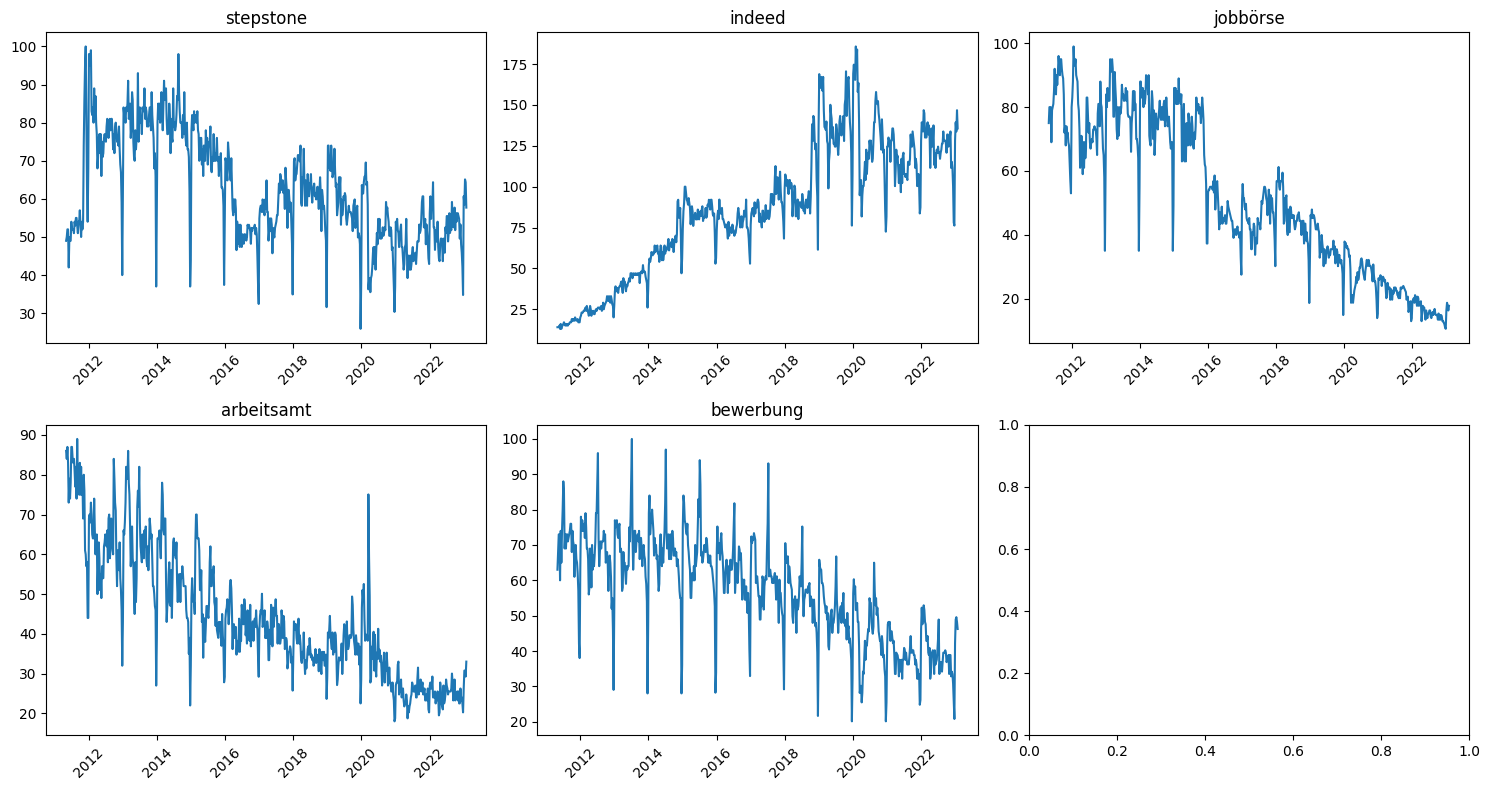

In [10]:
import matplotlib.pyplot as plt


keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, kw in zip(axes, keywords):
    ax.plot(df_week["Date"], df_week[kw])
    ax.set_title(kw)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Descriptives of the biweekly data

The structure for the plotting section 
- (i) we plot the GT variables of W12 against W34 prev
- (ii) we plot each of the GT variables against unemplyoment rate
- (iii) we will take as well a look at possible cross correlations
- (iv) we plot seasonality boxplots 
- (v) we use an normalized index plot to compare google trends in the respective time frame

## (i) plotting the biweekly data against each other over time

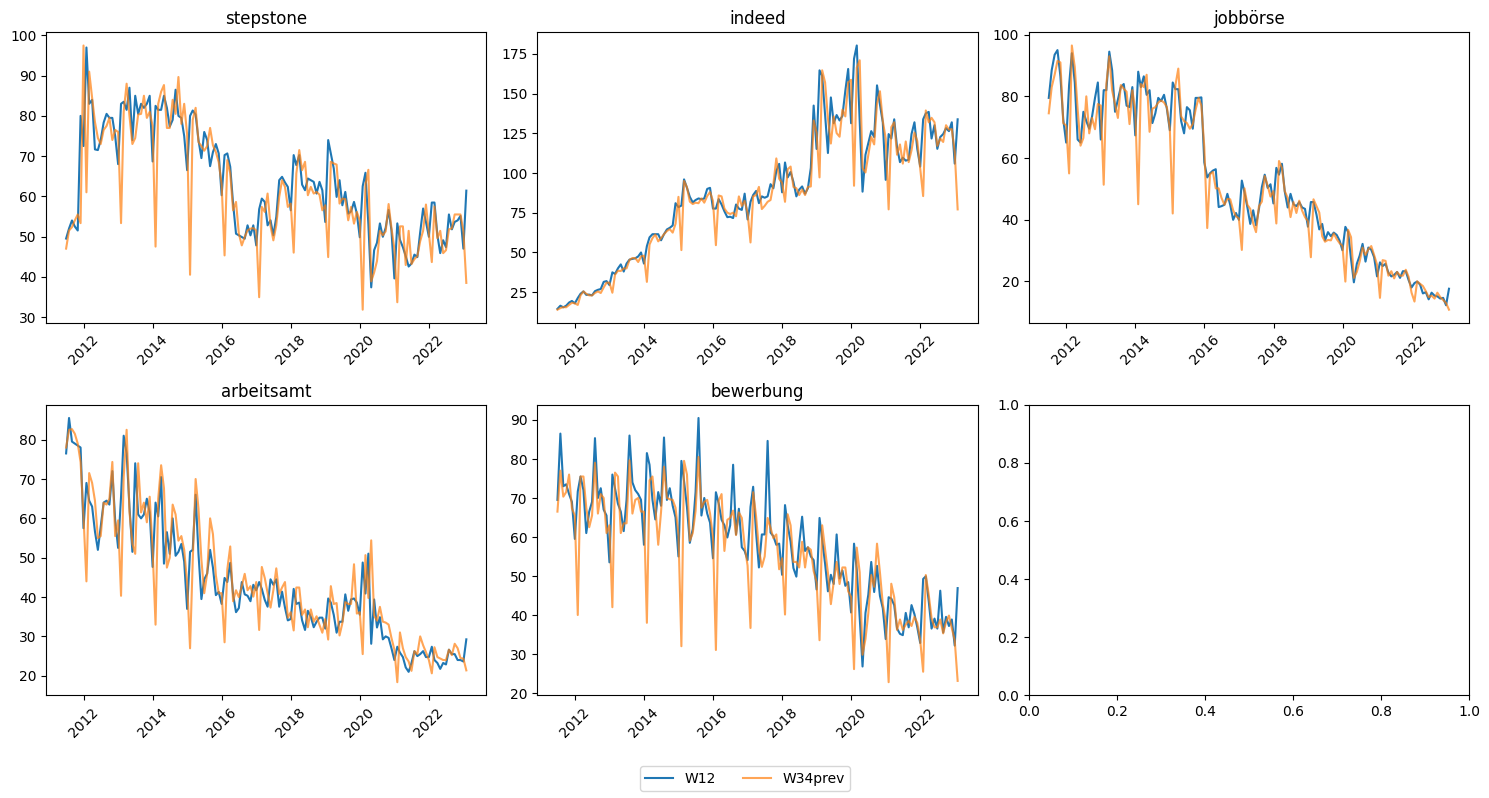

In [11]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, kw in zip(axes, keywords):
    ax.plot(panel.index, panel[f"{kw}_W12"], label="W12")
    ax.plot(panel.index, panel[f"{kw}_W34prev"], label="W34prev", alpha=0.7)
    ax.set_title(kw)
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Both W12 and W34prev display highly regular and pronounced seasonal fluctuations, especially for the public–sector related terms arbeitsamt, jobbörse and bewerbung. These indicators follow a clear intra-year cycle with strong peaks at the turn of the year and troughs during summer months.
Especially W34prev tends to exhibit sharper seasonal spikes than the corresponding W12. This pattern is particularly visible for bewerbung and arbeitsamt, or also the first years of jobbörse.
We could maybe say the W34prev component captures search behaviour that takes place before the measurement of month M's unemployment and is unaffected by the publication of the unemployment M-1, whereas the W12 component partly reflects reactions to official unemployment announcements at the end of the previous month. As a result, W34prev appears to retain a “cleaner” seasonal signal.
For indeed, jobbörse, arbeitsamt and bewerbubg the long-run trend component is clear.
Searches for jobbörse and arbeitsamt exhibit a persistent downward trend over 2011–2023, consistent with declining usage of the public employment service's online channels.
On the other hand indeed shows a strong upward trajectories during the 2010s, reflecting the structural an increase when it comes toGerman job search over the years .
The series for bewerbung shows a gradual, monotonic decline, consistent with the reduced use of generic application-related searches due to templates, automated systems, and platform-driven application processes.
Interesting is that arbeitsamt indeed and stepstone feature episodic bursts, most notably around 2020–2021 during the COVID-19 shock. These spikes suggest heightened job-search uncertainty during periods of macroeconomic stress and motivate the use of models capable of capturing such nonlinearities.
Bewerbung and jobbörse on the other hand are not that affected and the trend remains to clear to see maybe also a consequence of the decline in suage or not the interest.
Overall the biweekly aggregation looks internally coherent and that both series track similar underlying behavioural patterns, with W34prev often showing a clearer seasonal structure.


## (ii) Plotting the GT against unemployment iver time 
- first for W34 prev

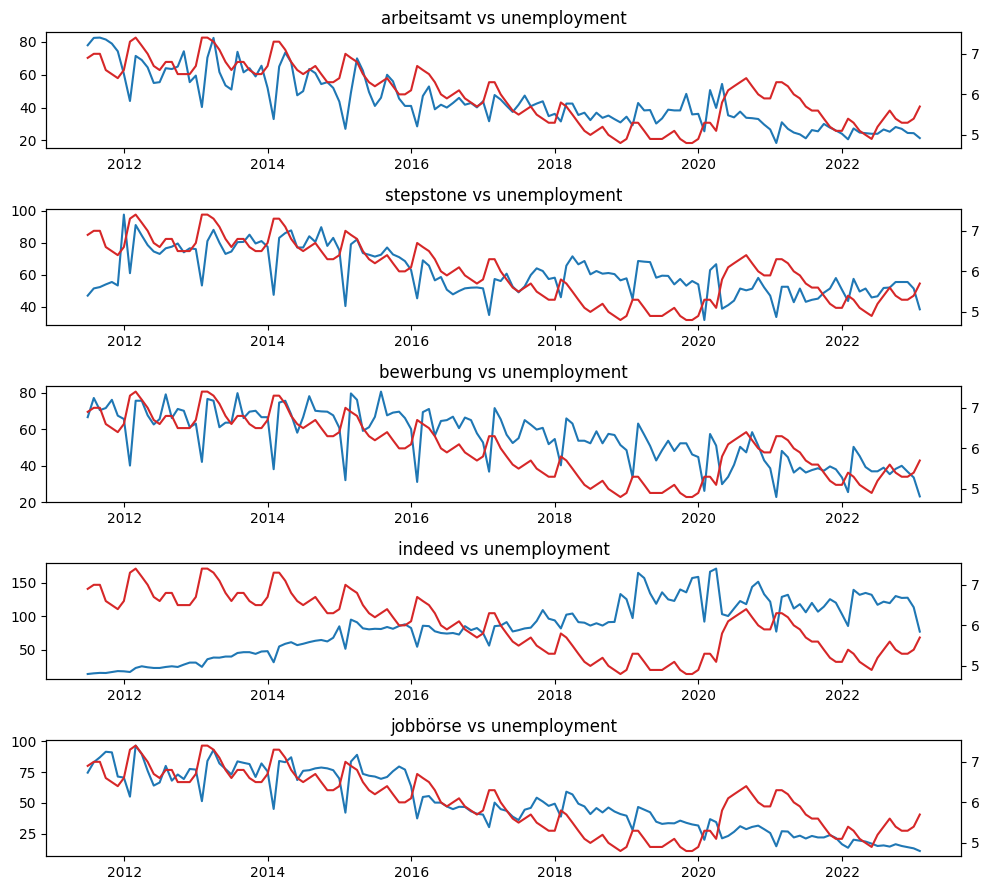

In [12]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9))

for ax, kw in zip(axes, ["arbeitsamt", "stepstone", "bewerbung","indeed","jobbörse"]):
    ax2 = ax.twinx()
    ax.plot(panel.index, panel[f"{kw}_W34prev"], label=f"{kw} (W34prev)", color="tab:blue")
    ax2.plot(panel.index, panel["Unemp"], label="Unemployment", color="tab:red")
    ax.set_title(f"{kw} vs unemployment")

plt.tight_layout()
plt.show()


- for W12

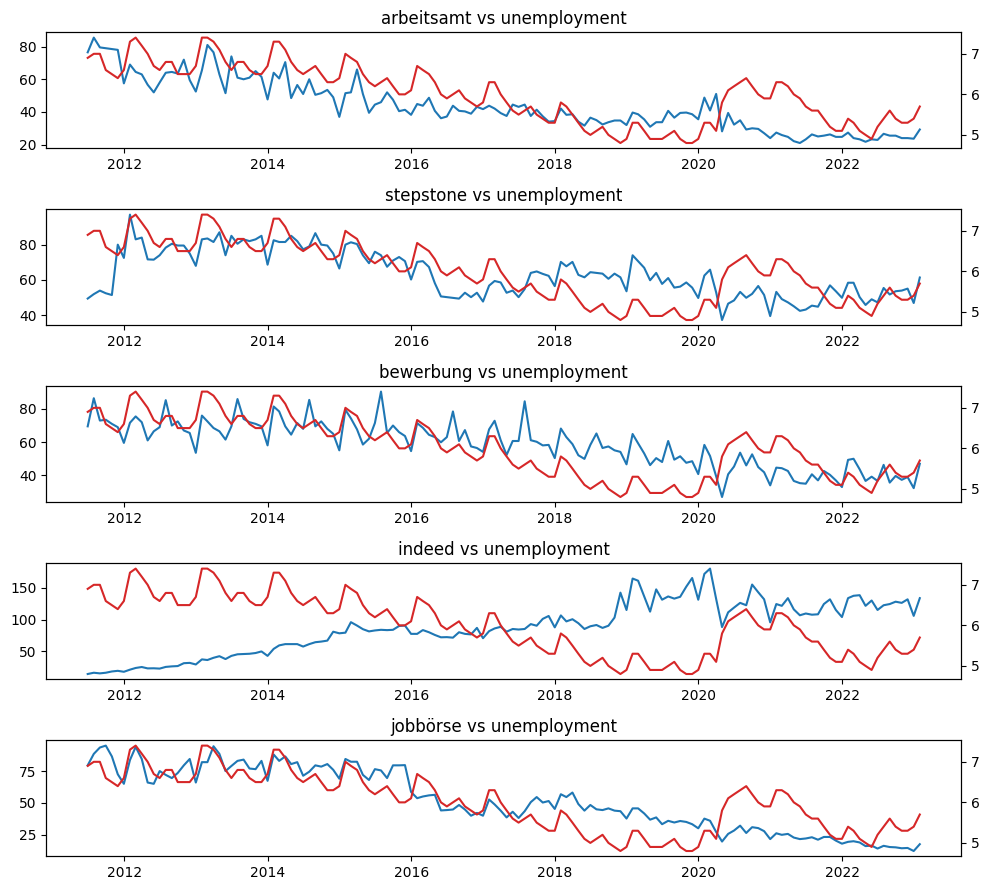

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9))

for ax, kw in zip(axes, ["arbeitsamt", "stepstone", "bewerbung","indeed","jobbörse"]):
    ax2 = ax.twinx()
    ax.plot(panel.index, panel[f"{kw}_W12"], label=f"{kw} (W12)", color="tab:blue")
    ax2.plot(panel.index, panel["Unemp"], label="Unemployment", color="tab:red")
    ax.set_title(f"{kw} vs unemployment")

plt.tight_layout()
plt.show()


## (iii) Cross correlation functions

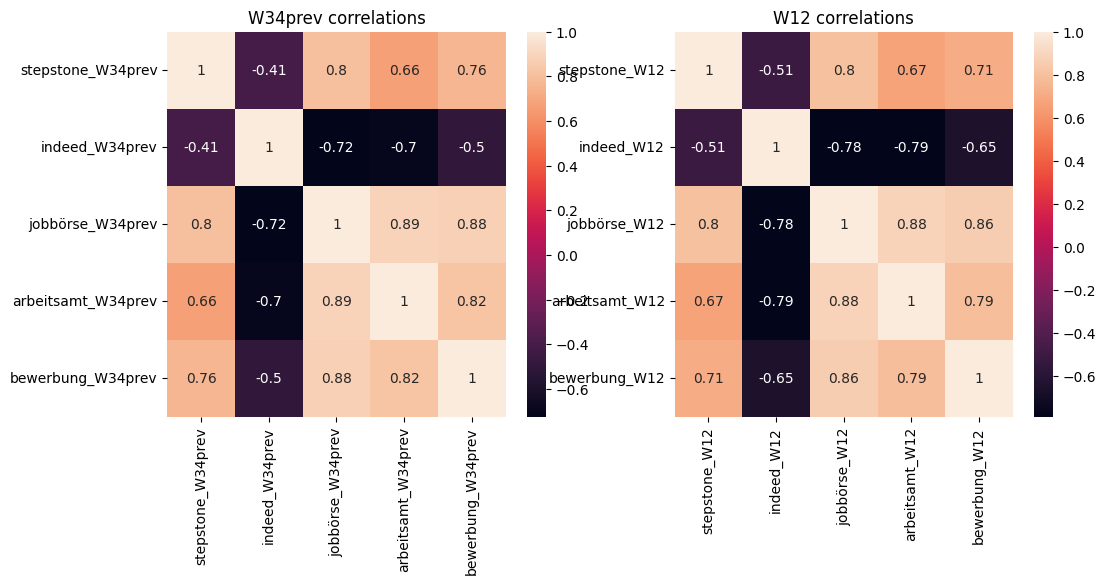

In [14]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(panel[[c for c in panel.columns if "W34prev" in c]].corr(), ax=axes[0], annot=True)
sns.heatmap(panel[[c for c in panel.columns if "W12" in c]].corr(), ax=axes[1], annot=True)
axes[0].set_title("W34prev correlations")
axes[1].set_title("W12 correlations")
plt.show()


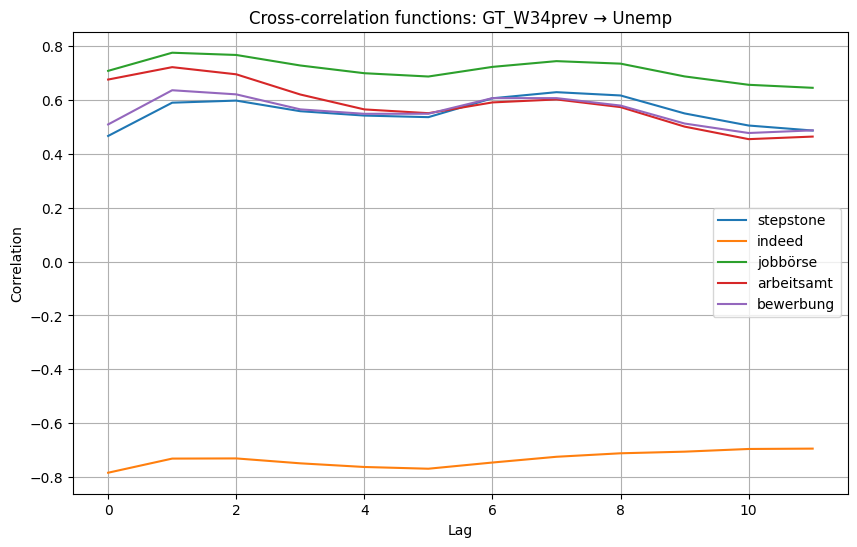

In [15]:
from statsmodels.tsa.stattools import ccf

lags = 12

plt.figure(figsize=(10, 6))

for kw in keywords:
    x = panel[f"{kw}_W34prev"]
    y = panel["Unemp"]
    corr = ccf(x, y)[:lags]
    plt.plot(range(lags), corr, label=f"{kw}")

plt.title("Cross-correlation functions: GT_W34prev → Unemp")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True)
plt.show()

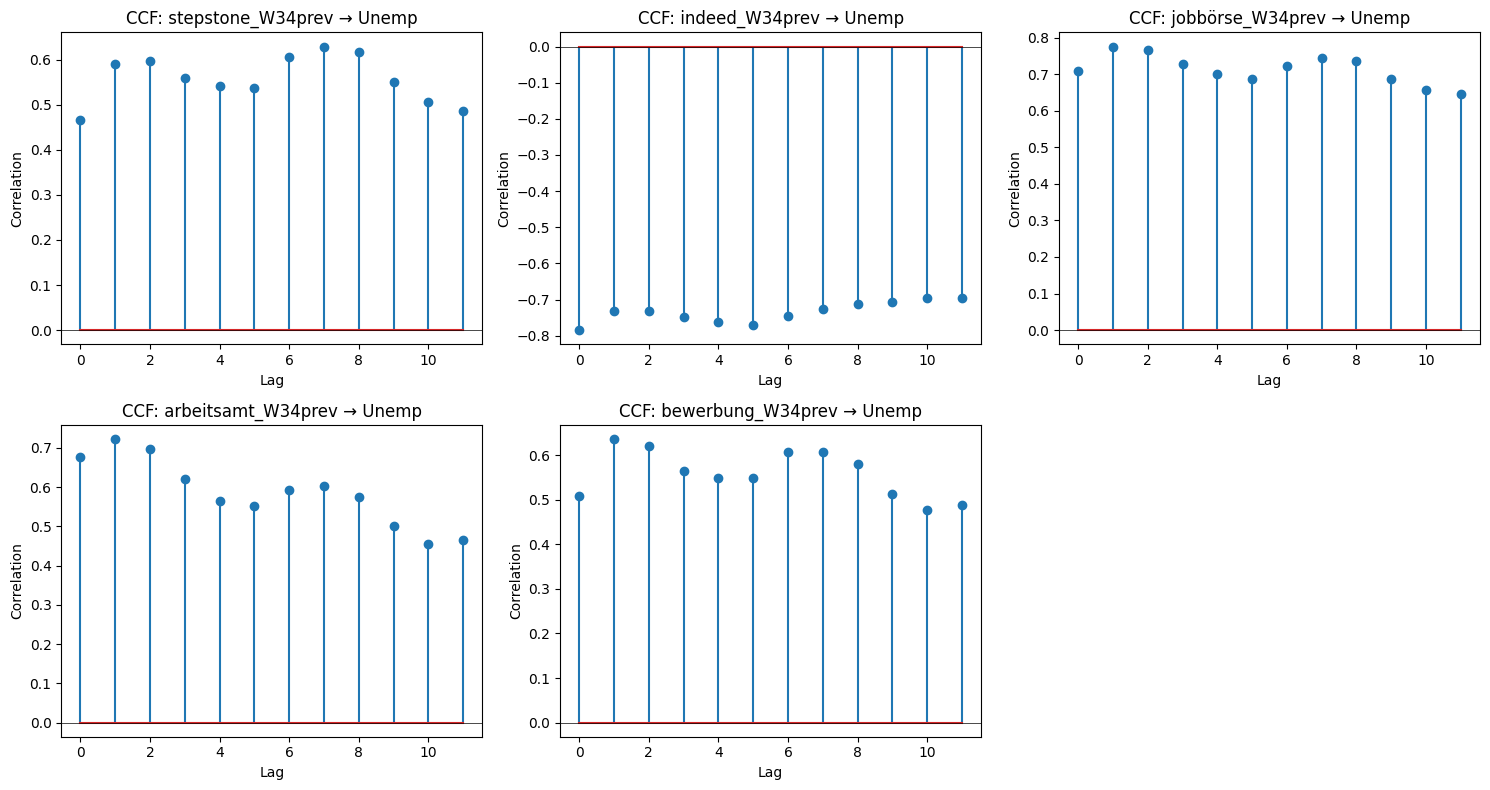

In [16]:
from statsmodels.tsa.stattools import ccf


lags = 12
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, kw in zip(axes, keywords):
    x = panel[f"{kw}_W34prev"].astype(float).values
    y = panel["Unemp"].astype(float).values

    corr = ccf(x, y)[:lags]

    ax.stem(range(lags), corr)    # <-- FIXED
    ax.axhline(0, color="black", linewidth=0.5)

    ax.set_title(f"CCF: {kw}_W34prev → Unemp")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Correlation")

# Hide unused subplot
for ax in axes[len(keywords):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## (iv) Seasonality boxplots

- for W34 prev

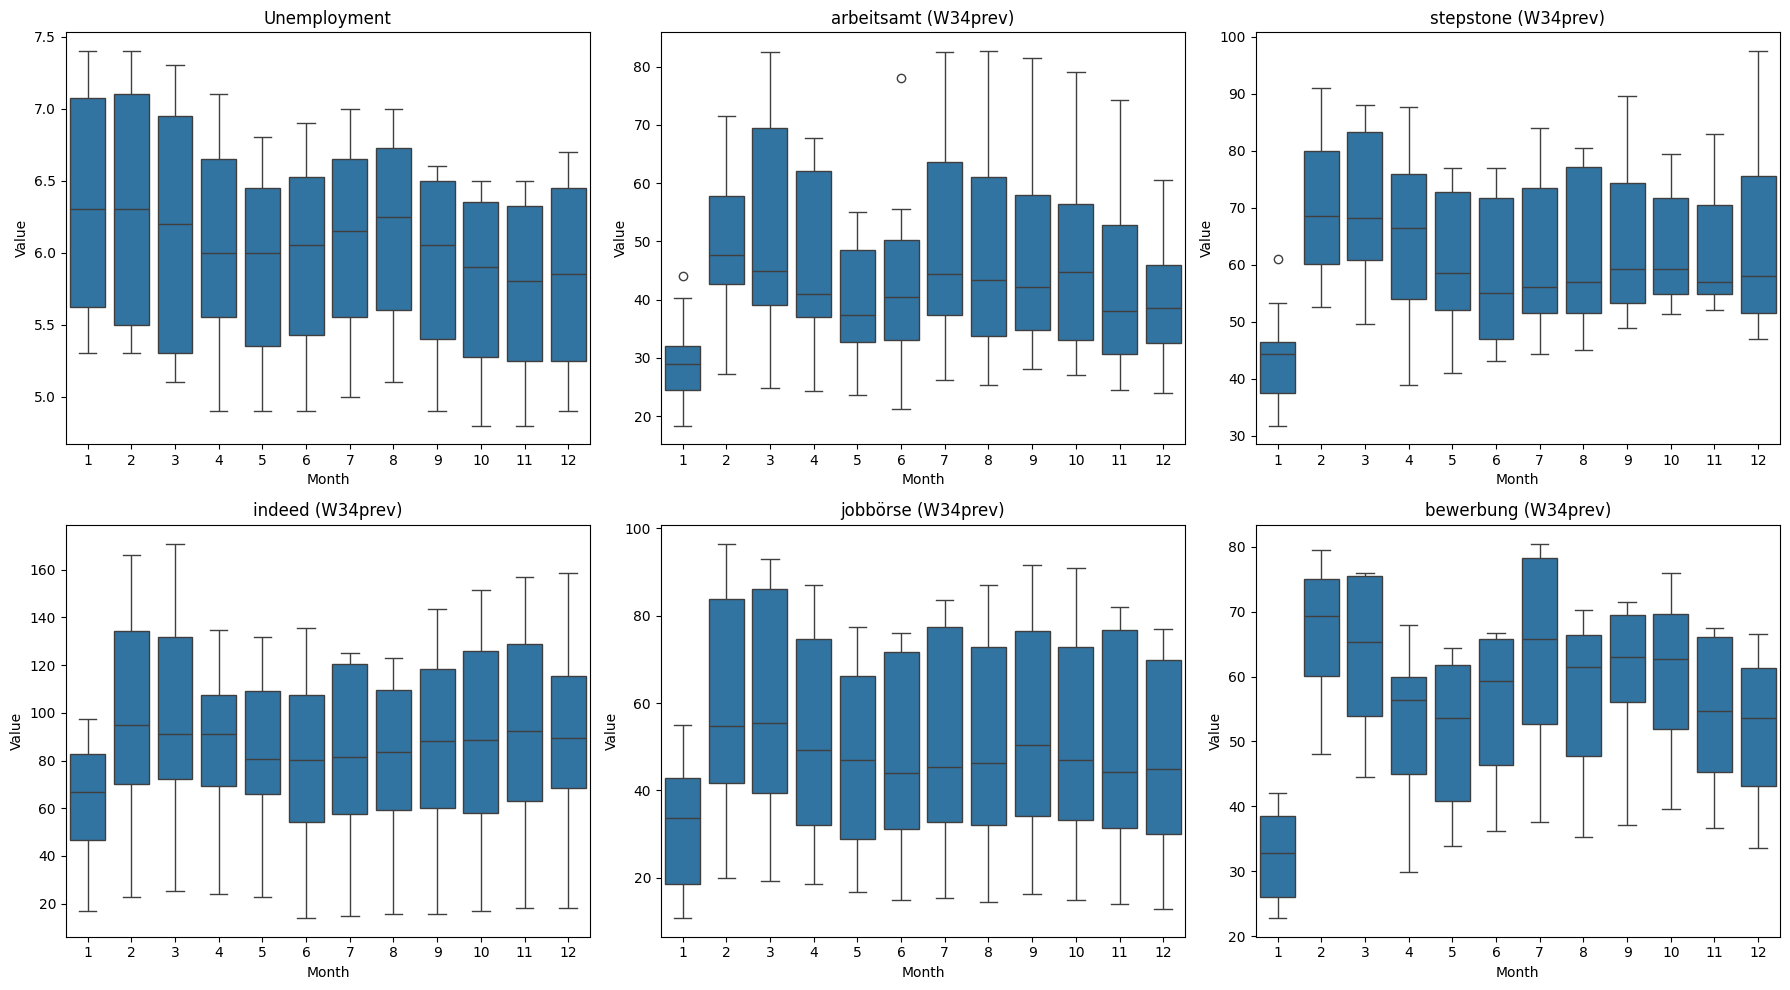

In [17]:
import seaborn as sns


# Ensure month column exists
panel["month"] = panel.index.month

# Order of variables shown in the grid
vars_to_plot = [
    "Unemp",
    "arbeitsamt_W34prev",
    "stepstone_W34prev",
    "indeed_W34prev",
    "jobbörse_W34prev",
    "bewerbung_W34prev"
]

titles = [
    "Unemployment",
    "arbeitsamt (W34prev)",
    "stepstone (W34prev)",
    "indeed (W34prev)",
    "jobbörse (W34prev)",
    "bewerbung (W34prev)"
]

# Create 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, var, title in zip(axes, vars_to_plot, titles):
    sns.boxplot(x="month", y=var, data=panel, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


- for W12

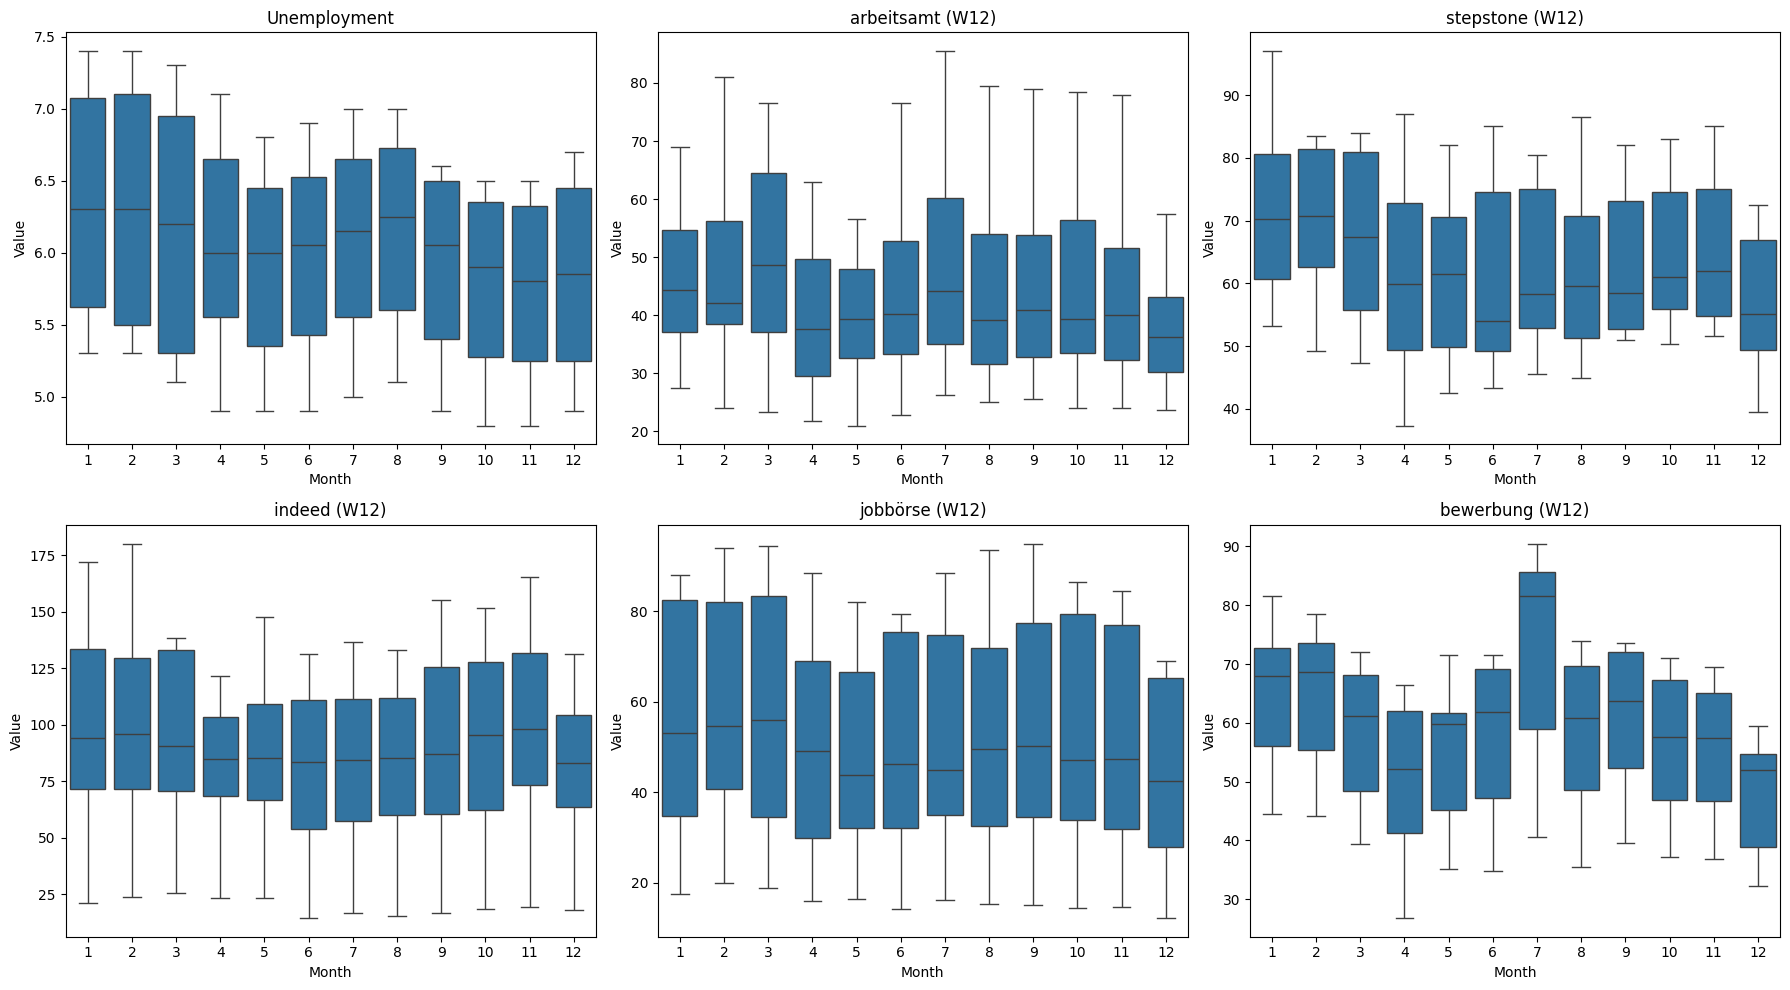

In [18]:


# Order of variables shown in the grid
vars_to_plot = [
    "Unemp",
    "arbeitsamt_W12",
    "stepstone_W12",
    "indeed_W12",
    "jobbörse_W12",
    "bewerbung_W12"
]

titles = [
    "Unemployment",
    "arbeitsamt (W12)",
    "stepstone (W12)",
    "indeed (W12)",
    "jobbörse (W12)",
    "bewerbung (W12)"
]

# Create 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, var, title in zip(axes, vars_to_plot, titles):
    sns.boxplot(x="month", y=var, data=panel, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


## (v) Normalized index plot

- for W12

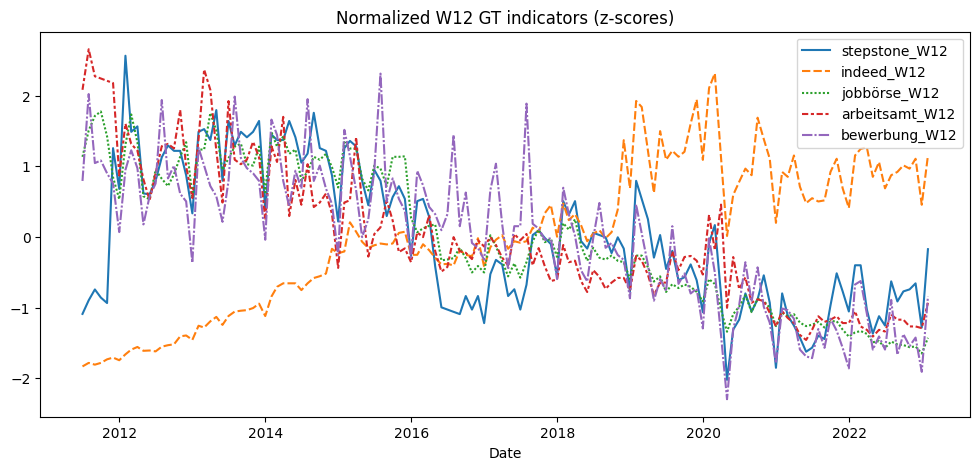

In [19]:

gt_cols = [col for col in panel.columns if "W12" in col]
gt_norm = (panel[gt_cols] - panel[gt_cols].mean()) / panel[gt_cols].std()

plt.figure(figsize=(12,5))
sns.lineplot(data=gt_norm)
plt.title("Normalized W12 GT indicators (z-scores)")
plt.show()


- for W34 prev

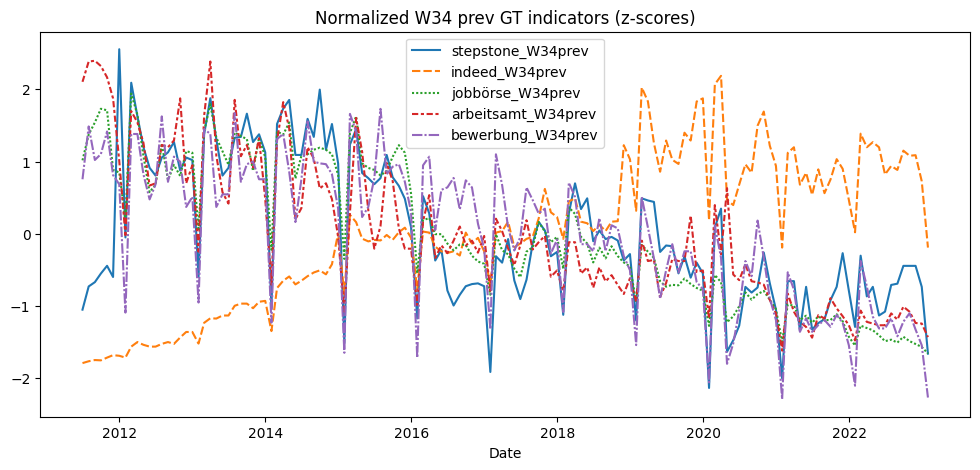

In [20]:

gt_cols = [col for col in panel.columns if "W34prev" in col]
gt_norm = (panel[gt_cols] - panel[gt_cols].mean()) / panel[gt_cols].std()

plt.figure(figsize=(12,5))
sns.lineplot(data=gt_norm)
plt.title("Normalized W34 prev GT indicators (z-scores)")
plt.show()

# Stationarity tests for the variables

- the biweekly variables

In [21]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller


MIN_LEN = 20
MAXLAG = 13           # upper bound for monthly data 
OUT_CSV = "adf_panel_simple.csv"

def run_adf(series: pd.Series,
            name: str,
            maxlag: int = MAXLAG,
            min_len: int = MIN_LEN) -> pd.DataFrame:

    series = pd.to_numeric(series, errors="coerce")
    series = series.dropna()

    results = []
    cols = [
        "series", "transform", "reg",
        "adf_stat", "pvalue",
        "used_lag", "nobs_eff", "nobs_raw",
        "crit_1pct", "crit_5pct", "crit_10pct",
        "reject_1pct", "reject_5pct", "reject_10pct"
    ]

    def run_one(x, transform_label):
        x = pd.Series(x).dropna()
        nraw = x.shape[0]

        if nraw < min_len:
            for reg in ("n", "c", "ct"):
                results.append((name, transform_label, reg,
                                np.nan, np.nan,
                                np.nan, np.nan, nraw,
                                np.nan, np.nan, np.nan,
                                False, False, False))
            return

        for reg in ("n", "c", "ct"):
            stat, p, usedlag, nobs, crit, icbest = adfuller(
                x,
                regression=reg,          
                maxlag=maxlag,
                autolag="AIC"             # lag chosen by AIC
            )
            c1, c5, c10 = crit["1%"], crit["5%"], crit["10%"]

            # reject if statistic is more negative than critical value
            r1 = stat < c1
            r5 = stat < c5
            r10 = stat < c10

            results.append((name, transform_label, reg,
                            stat, p,
                            usedlag, nobs, nraw,
                            c1, c5, c10,
                            r1, r5, r10))

    # Level
    run_one(series, "level")
    # First difference
    run_one(series.diff(), "diff1")

    return pd.DataFrame(results, columns=cols)




all_res = []

for col in panel.columns:
    res = run_adf(panel[col], name=col)
    all_res.append(res)

    print("\n" + "="*70)
    print(f"ADF results for {col}")
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res.to_string(index=False))

adf_summary = pd.concat(all_res, ignore_index=True)
adf_summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved ADF summary to {OUT_CSV}")



ADF results for stepstone_W12
       series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone_W12     level   n   -0.9831  0.2949        12       127       140    -2.5836    -1.9433     -1.6149        False        False         False
stepstone_W12     level   c   -1.6889  0.4368        13       126       140    -3.4833    -2.8848     -2.5792        False        False         False
stepstone_W12     level  ct   -2.5111  0.3224        13       126       140    -4.0325    -3.4459     -3.1478        False        False         False
stepstone_W12     diff1   n   -3.2242  0.0013        11       127       139    -2.5836    -1.9433     -1.6149         True         True          True
stepstone_W12     diff1   c   -3.2986  0.0149        11       127       139    -3.4829    -2.8846     -2.5791        False         True          True
stepstone_W12     diff1  ct   -3.2441  0.0760        11       127    

- the standard weekly variables

In [22]:
# removing the week index for the dickey fuller test as it is a constant 
week_stat = df_week.copy()
week_stat.drop(columns="Date", axis = 1, inplace=True)
# defining the upper bound for the weekly data
MIN_LEN = 20
MAXLAG = 52          

all_res = []

for col in week_stat.columns:
    res = run_adf(week_stat[col], name=col)
    all_res.append(res)

    print("\n" + "="*70)
    print(f"ADF results for {col}")
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res.to_string(index=False))

adf_summary = pd.concat(all_res, ignore_index=True)



ADF results for stepstone
   series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone     level   n   -0.3352  0.5624        13       600       614    -2.5695    -1.9415     -1.6164        False        False         False
stepstone     level   c   -2.3279  0.1631        12       601       614    -3.4413    -2.8664     -2.5693        False        False         False
stepstone     level  ct   -4.9716  0.0002         8       605       614    -3.9738    -3.4178     -3.1313         True         True          True
stepstone     diff1   n  -10.1611  0.0000        12       600       613    -2.5695    -1.9415     -1.6164         True         True          True
stepstone     diff1   c  -10.1526  0.0000        12       600       613    -3.4413    -2.8664     -2.5693         True         True          True
stepstone     diff1  ct  -10.1639  0.0000        12       600       613    -3.9739    -3.4178    

# Checking the biweekly variables on cointegration

In [23]:

import statsmodels.api as sm



# Adjust this to your actual DataFrame name
df = panel.copy()  # or panel.copy()

Y_COL = "Unemp"

# List all biweekly GT variables you want to test
GT_COLS = [
    "stepstone_W12",
    "indeed_W12",
    "jobbörse_W12",
    "arbeitsamt_W12",
    "bewerbung_W12",
    "stepstone_W34prev",
    "indeed_W34prev",
    "jobbörse_W34prev",
    "arbeitsamt_W34prev",
    "bewerbung_W34prev",
]

# --------------------------------------------------
# Helper: build monthly dummies
# --------------------------------------------------

def add_month_dummies(df, drop_first=True, prefix="m"):
    """Add 11 monthly dummies (for 12 months) to a DataFrame based on its DatetimeIndex."""
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Index must be a DatetimeIndex to create month dummies.")
    month = df.index.month
    dummies = pd.get_dummies(month, prefix=prefix, dtype=float)
    if drop_first:
        dummies = dummies.iloc[:, 1:]
    return df.join(dummies)

# --------------------------------------------------
# Engle–Granger test for one GT variable
# --------------------------------------------------

from statsmodels.tsa.stattools import coint

def engle_granger_simple(df, y_col, x_col):
    data = df[[y_col, x_col]].dropna()
    y = data[y_col]
    x = data[x_col]

    stat, pvalue, crit = coint(y, x, trend="c")  # Case 2

    return {
        "series": x_col,
        "eg_stat": stat,
        "pvalue": pvalue,
        "crit_1pct": crit[0],
        "crit_5pct": crit[1],
        "crit_10pct": crit[2],
        "reject_5pct": stat < crit[1],
    }


In [24]:
eg_results = []
for col in GT_COLS:
    eg_results.append(engle_granger_simple(panel, "Unemp", col))

eg_summary = pd.DataFrame(eg_results)
print(eg_summary)


               series   eg_stat    pvalue  crit_1pct  crit_5pct  crit_10pct  \
0       stepstone_W12 -2.577911  0.245829  -3.976966  -3.380441   -3.075103   
1          indeed_W12 -2.958391  0.120430  -3.976966  -3.380441   -3.075103   
2        jobbörse_W12 -2.858216  0.147863  -3.976966  -3.380441   -3.075103   
3      arbeitsamt_W12 -3.168235  0.075403  -3.976966  -3.380441   -3.075103   
4       bewerbung_W12 -2.377943  0.335371  -3.976966  -3.380441   -3.075103   
5   stepstone_W34prev -2.588815  0.241362  -3.976966  -3.380441   -3.075103   
6      indeed_W34prev -3.485516  0.033701  -3.976966  -3.380441   -3.075103   
7    jobbörse_W34prev -3.203768  0.069300  -3.976966  -3.380441   -3.075103   
8  arbeitsamt_W34prev -2.956172  0.120994  -3.976966  -3.380441   -3.075103   
9   bewerbung_W34prev -2.394768  0.327337  -3.976966  -3.380441   -3.075103   

   reject_5pct  
0        False  
1        False  
2        False  
3        False  
4        False  
5        False  
6         T

# Nowcasting framework

In [25]:
# these are some of the important packages i need 
import statsmodels.api as sm
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit



In [26]:
# --- mandatory weekly_panel fix ---
assert "Date" in df_week.columns, "df_week must still contain a Date column at this step."

df_week = df_week.copy()
df_week["Date"] = pd.to_datetime(df_week["Date"], errors="coerce").dt.tz_localize(None)
df_week = df_week.sort_values("Date")

weekly_cols = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]
weekly_panel = df_week.set_index("Date")[weekly_cols].sort_index()

# sanity checks
print(weekly_panel.index.min(), weekly_panel.index.max())
print(weekly_panel.index[:5])


2011-05-01 00:00:00 2023-01-29 00:00:00
DatetimeIndex(['2011-05-01', '2011-05-08', '2011-05-15', '2011-05-22',
               '2011-05-29'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [27]:
weekly_panel

,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
Date,,,,,
2011-05-01,49.000000,14.000000,75.000000,86.000000,63.000000
2011-05-08,50.000000,14.000000,80.000000,84.000000,68.000000
2011-05-15,52.000000,14.000000,80.000000,87.000000,73.000000
2011-05-22,52.000000,15.000000,80.000000,83.000000,73.000000
2011-05-29,42.000000,13.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...
2023-01-01,60.670120,128.215336,16.313392,26.270023,42.207649
2023-01-08,58.450482,139.364496,18.712420,30.773455,48.907276
2023-01-15,65.109398,133.789916,17.752809,30.773455,49.577239


a check for the panel dataset to see whether it still contains the date column

In [28]:

panel = panel.copy()
panel.index = pd.to_datetime(panel.index, errors="coerce").tz_localize(None)
panel = panel.sort_index()

assert "Unemp" in panel.columns
assert panel.index.is_month_end.all()
panel.head()


,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp,month
Date,,,,,,,,,,,,
2011-06-30,49.5,14.5,79.5,76.5,69.5,47.000000,14.000000,74.5,78.000000,66.500000,6.9,6
2011-07-31,52.0,16.5,88.5,85.5,86.5,51.500000,15.000000,83.0,82.500000,77.000000,7.0,7
2011-08-31,54.0,15.5,93.5,79.5,73.0,52.333333,15.666667,87.0,82.666667,70.333333,7.0,8
2011-09-30,52.5,16.5,95.0,79.0,73.5,54.000000,15.500000,91.5,81.500000,71.500000,6.6,9
2011-10-31,51.5,18.5,86.5,78.5,71.0,55.500000,17.000000,91.0,79.000000,76.000000,6.5,10


## configuration code

In [29]:
from dataclasses import dataclass
from typing import Tuple

@dataclass
class CFG:
    # Sample endpoints
    start_week: str = "2011-05-01"
    end_week: str   = "2023-01-29"
    start_month: str = "2011-06-30"
    end_month: str   = "2023-01-31"

    # Evaluation timeframe
    eval_start: str = "2019-01-31"
    min_train: int = 60

    # Deterministics / transformations
    seasonal_dummies: bool = True
    target_transform: str = "diff"   # keep diff for nowcasting baseline

    # Lag selection controls
    ar_max_p: int = 6
    arx_max_p: int = 4
    arx_max_q: int = 2
    ic: str = "BIC"                  # AIC or BIC

    # MIDAS controls
    midas_K_candidates: Tuple[int, ...] = (4, 6, 8)
    midas_include_ar: bool = True
    midas_diff_weekly: bool = True

cfg = CFG()


In [30]:
def build_umidas_design(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    K: int = 8,
    target_transform: str = "diff",   # "diff" or "level"
    weekly_transform: str = "diff",   # "diff" or "level"
    seasonal_dummies: bool = True,
    drop_first_dummy: bool = True
) -> pd.DataFrame:


    # --- Ensure proper indices
    wk = weekly_panel[[gt_col]].copy().sort_index()
    wk.index = pd.to_datetime(wk.index).tz_localize(None)

    U = unemp_monthly.copy().sort_index()
    U.index = pd.to_datetime(U.index).tz_localize(None)

    # --- Transform target and weekly regressor
    y = U.diff() if target_transform == "diff" else U
    x = wk[gt_col].diff() if weekly_transform == "diff" else wk[gt_col]

    # --- Build rows
    rows = []
    idx = []
    for t in y.index:
        if pd.isna(y.loc[t]):
            continue
        x_up_to_t = x.loc[x.index <= t].dropna()
        if len(x_up_to_t) < K:
            continue

        lastK = x_up_to_t.iloc[-K:]  # oldest..newest
        # define wlag0 = most recent week, wlag1 = one week older, ...
        vals = lastK.iloc[::-1].values

        rows.append([y.loc[t]] + list(vals))
        idx.append(t)

    cols = ["y"] + [f"wlag{k}" for k in range(K)]
    design = pd.DataFrame(rows, index=pd.to_datetime(idx), columns=cols).sort_index()

    # --- Optional seasonal dummies on monthly index
    if seasonal_dummies:
        d = pd.get_dummies(design.index.month, prefix="m", drop_first=drop_first_dummy).astype(float)
        d.index = design.index
        design = pd.concat([design, d], axis=1)

    return design


In [31]:
EVAL_START = cfg.eval_start
MIN_TRAIN  = cfg.min_train

def compute_metrics(pred: pd.Series, act: pd.Series) -> dict:
    pred, act = pred.align(act, join="inner")
    err = pred - act
    return {
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "MAE": float(np.mean(np.abs(err))),
        "n": int(err.shape[0]),
    }

def month_dummies(index: pd.DatetimeIndex, drop_first=True) -> pd.DataFrame:
    d = pd.get_dummies(index.month, prefix="m", drop_first=drop_first).astype(float)
    d.index = index
    return d


# residualize y and X against dummies

In [32]:
def partial_out_dummies(
    D: pd.DataFrame,
    y: pd.Series,
    X: pd.DataFrame
):
    """
    Partial out (residualize) y and each column of X with respect to D (incl. intercept).
    Returns:
      y_tilde: residualized y
      X_tilde: residualized X
      gamma_hat: OLS coefficients for y ~ D
      A_hat: OLS coefficients for each X_j ~ D (matrix with shape [n_D, n_X])
    """

    # Add intercept to D
    Dm = D.copy()
    Dm.insert(0, "const", 1.0)

    # Convert to numpy
    Dv = Dm.values
    yv = y.values.reshape(-1, 1)
    Xv = X.values

    # Solve OLS via least squares: minimize ||y - D*gamma||
    gamma_hat, *_ = np.linalg.lstsq(Dv, yv, rcond=None)  # [n_D, 1]
    y_hat = Dv @ gamma_hat
    y_tilde = (yv - y_hat).ravel()

    # For X: solve for each column jointly: X ≈ D*A
    A_hat, *_ = np.linalg.lstsq(Dv, Xv, rcond=None)     # [n_D, n_X]
    X_hat = Dv @ A_hat
    X_tilde = Xv - X_hat

    y_tilde = pd.Series(y_tilde, index=y.index, name=y.name)
    X_tilde = pd.DataFrame(X_tilde, index=X.index, columns=X.columns)

    return y_tilde, X_tilde, gamma_hat, A_hat, Dm.columns


In [33]:
from typing import Optional, Tuple

def ic_value(res, ic: str) -> float:
    ic = ic.upper()
    if ic == "AIC":
        return float(res.aic)
    elif ic == "BIC":
        return float(res.bic)
    else:
        raise ValueError("ic must be 'AIC' or 'BIC'")

def select_ar_p(y: pd.Series, max_p: int, ic: str, dummies: Optional[pd.DataFrame]) -> int:
    best = (np.inf, 1)
    for p in range(1, max_p + 1):
        df = pd.concat([y] + [y.shift(j) for j in range(1, p + 1)], axis=1)
        df.columns = ["y"] + [f"lag{j}" for j in range(1, p + 1)]
        if dummies is not None:
            df = df.join(dummies)
        df = df.dropna()
        if df.empty:
            continue
        res = sm.OLS(df["y"], sm.add_constant(df.drop(columns=["y"]), has_constant="add")).fit()
        val = ic_value(res, ic)
        if val < best[0]:
            best = (val, p)
    return best[1]

def select_arx_pq(y: pd.Series, x: pd.Series, max_p: int, max_q: int, ic: str, dummies: Optional[pd.DataFrame]) -> Tuple[int, int]:
    best = (np.inf, 1, 0)
    base = pd.concat([y.rename("y"), x.rename("x")], axis=1)

    for p in range(1, max_p + 1):
        for q in range(0, max_q + 1):
            df = base.copy()
            for j in range(1, p + 1):
                df[f"y_lag{j}"] = df["y"].shift(j)
            for k in range(0, q + 1):
                df[f"x_lag{k}"] = df["x"].shift(k)
            if dummies is not None:
                df = df.join(dummies)
            df = df.dropna()
            if df.empty:
                continue
            res = sm.OLS(df["y"], sm.add_constant(df.drop(columns=["y"]), has_constant="add")).fit()
            val = ic_value(res, ic)
            if val < best[0]:
                best = (val, p, q)
    return best[1], best[2]



In [34]:
def select_alpha_tscv(
    X: pd.DataFrame,
    y: pd.Series,
    model: str,
    alphas,
    n_splits: int = 5
) -> float:
    """
    Time-series CV for ridge/lasso on (already residualized) data.
    Uses expanding folds, minimizing MSE.
    """

    Xv = X.values
    yv = y.values

    # Guard against too many splits for short samples
    if len(yv) < (n_splits + 1):
        n_splits = max(2, min(n_splits, len(yv) - 1))

    tscv = TimeSeriesSplit(n_splits=n_splits)

    best_alpha, best_mse = None, np.inf

    for a in alphas:
        if model == "ridge":
            est = Pipeline([
                ("scaler", StandardScaler()),
                ("mdl", Ridge(alpha=a, fit_intercept=False))
            ])
        elif model == "lasso":
            est = Pipeline([
                ("scaler", StandardScaler()),
                ("mdl", Lasso(alpha=a, max_iter=20000, fit_intercept=False))
            ])
        else:
            raise ValueError("model must be 'ridge' or 'lasso'")

        mses = []
        for train_idx, test_idx in tscv.split(Xv):
            est.fit(Xv[train_idx], yv[train_idx])
            yhat = est.predict(Xv[test_idx])
            mses.append(float(np.mean((yv[test_idx] - yhat) ** 2)))

        mse = float(np.mean(mses))
        if mse < best_mse:
            best_mse, best_alpha = mse, a

    return float(best_alpha)


In [35]:
# result container
@dataclass
class Result:
    name: str
    pred: pd.Series
    act: pd.Series
    err: pd.Series
    metrics: Dict[str, float]
    meta: Dict[str, object]


## Constructing the nowcast models 

In [36]:
def nowcast_ar_diff(panel: pd.DataFrame, start_eval: str,
                    p: int = 2, min_train: int = 60,
                    seasonal_dummies: bool = True):
    df = panel[["Unemp"]].copy()
    U = pd.to_numeric(df["Unemp"], errors="coerce")
    dU = U.diff()

    for j in range(1, p + 1):
        df[f"dU_lag{j}"] = dU.shift(j)

    dummies = month_dummies(df.index) if seasonal_dummies else None
    reg_cols = [f"dU_lag{j}" for j in range(1, p + 1)]
    

    preds, acts, idx = [], [], []
    phi_path = []

    for t in df.loc[start_eval:].index:
        est = df.loc[df.index < t].copy()
        est["dU"] = dU.loc[est.index]
        est = est.dropna(subset=["dU"] + reg_cols)

        if len(est) < min_train:
            continue

        X = est[reg_cols]
        if dummies is not None:
            X = pd.concat([X, dummies.loc[X.index]], axis=1)
        X = sm.add_constant(X, has_constant="add")

        res = sm.OLS(est["dU"], X).fit()
        phi_path.append((t, res.params["dU_lag1"]))

        x_t = df.loc[[t], reg_cols]
        if dummies is not None:
            x_t = pd.concat([x_t, dummies.loc[[t]]], axis=1)
        x_t = sm.add_constant(x_t, has_constant="add")

        dU_hat = float(res.predict(x_t))
        U_last = U.loc[U.index < t].iloc[-1]      # last observed before t
        U_hat = U_last + dU_hat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name="AR_pred")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act, phi_path


def nowcast_arx_diff(panel: pd.DataFrame, xcol: str, start_eval: str,
                     p: int = 2, q: int = 0,
                     min_train: int = 60,
                     seasonal_dummies: bool = True):

    df = panel[["Unemp", xcol]].copy()
    U = pd.to_numeric(df["Unemp"], errors="coerce")
    Xraw = pd.to_numeric(df[xcol], errors="coerce")

    dU = U.diff()
    dX = Xraw.diff()

    for j in range(1, p + 1):
        df[f"dU_lag{j}"] = dU.shift(j)

    df["dX_lag0"] = dX
    for k in range(1, q + 1):
        df[f"dX_lag{k}"] = dX.shift(k)

    dummies = month_dummies(df.index) if seasonal_dummies else None
    reg_cols = [f"dU_lag{j}" for j in range(1, p + 1)] + ["dX_lag0"] + [f"dX_lag{k}" for k in range(1, q + 1)]

    preds, acts, idx = [], [], []

    for t in df.loc[start_eval:].index:
        est = df.loc[df.index < t].copy()
        est["dU"] = dU.loc[est.index]
        est = est.dropna(subset=["dU"] + reg_cols)

        if len(est) < min_train:
            continue

        X = est[reg_cols]
        if dummies is not None:
            X = pd.concat([X, dummies.loc[X.index]], axis=1)
        X = sm.add_constant(X, has_constant="add")

        res = sm.OLS(est["dU"], X).fit()

        x_t = df.loc[[t], reg_cols]
        if dummies is not None:
            x_t = pd.concat([x_t, dummies.loc[[t]]], axis=1)
        x_t = sm.add_constant(x_t, has_constant="add")

        dU_hat = float(res.predict(x_t))
        U_last = U.loc[U.index < t].iloc[-1]
        U_hat = U_last + dU_hat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"ARX_pred_{xcol}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act




## U Midas nowcasting function

In [37]:
def nowcast_umidas(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    start_eval: str,
    K: int = 8,
    include_ar1: bool = True,
    target_transform: str = "diff",
    weekly_transform: str = "diff",
    seasonal_dummies: bool = True,
    min_train: int = 60
):
    design = build_umidas_design(
        weekly_panel=weekly_panel,
        unemp_monthly=unemp_monthly,
        gt_col=gt_col,
        K=K,
        target_transform=target_transform,
        weekly_transform=weekly_transform,
        seasonal_dummies=seasonal_dummies
    )

    # optional AR term in the monthly target (ΔU_{t-1})
    if include_ar1:
        design["y_lag1"] = design["y"].shift(1)

    reg_cols = [c for c in design.columns if c.startswith("wlag")]
    if include_ar1:
        reg_cols += ["y_lag1"]
    reg_cols += [c for c in design.columns if c.startswith("m_")]

    # monthly unemployment series (force month-end alignment)
    U = unemp_monthly.copy()
    U.index = pd.to_datetime(U.index).tz_localize(None)
    U.index = U.index.to_period("M").to_timestamp("M")
    U = U.sort_index()

    preds, acts, idx = [], [], []

    for t in design.loc[start_eval:].index:
        est = design.loc[design.index < t].dropna(subset=["y"] + reg_cols)
        if len(est) < min_train:
            continue

        # fit model
        X = sm.add_constant(est[reg_cols], has_constant="add")
        res = sm.OLS(est["y"], X).fit()

        # build forecast regressor row
        row_t = design.loc[[t], reg_cols]
        if row_t.isna().any(axis=1).iloc[0]:
            continue

        X_t = sm.add_constant(row_t, has_constant="add")
        yhat = float(res.predict(X_t))

        # convert back to level forecast
        if target_transform == "diff":
            U_last = U.loc[U.index < t].iloc[-1]
            U_hat = U_last + yhat
        else:
            U_hat = yhat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"MIDAS_pred_{gt_col}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act


def nowcast_umidas_penalized_partialout(
    weekly_panel: pd.DataFrame,
    unemp_monthly: pd.Series,
    gt_col: str,
    start_eval: str,
    K: int = 8,
    include_ar1: bool = True,
    target_transform: str = "diff",
    weekly_transform: str = "diff",
    seasonal_dummies: bool = True,
    min_train: int = 60,
    model: str = "ridge",  # "ridge" or "lasso"
    alphas: Tuple[float, ...] = (1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0),
    cv_splits: int = 5,
    refit_alpha_each_t: bool = True
):
    """
    Penalized U-MIDAS with dummies effectively unpenalized via partialling-out.
    Penalization applies only to weekly lags (and optional AR term).
    """

    design = build_umidas_design(
        weekly_panel=weekly_panel,
        unemp_monthly=unemp_monthly,
        gt_col=gt_col,
        K=K,
        target_transform=target_transform,
        weekly_transform=weekly_transform,
        seasonal_dummies=seasonal_dummies
    )

    if include_ar1:
        design["y_lag1"] = design["y"].shift(1)

    # Penalized regressors: weekly lags (+ optional AR term)
    pen_cols = [c for c in design.columns if c.startswith("wlag")]
    if include_ar1:
        pen_cols += ["y_lag1"]

    # Unpenalized controls: monthly dummies (if present)
    dum_cols = [c for c in design.columns if c.startswith("m_")] if seasonal_dummies else []

    # Monthly unemployment level for converting diffs to levels
    U = unemp_monthly.copy()
    U.index = pd.to_datetime(U.index).tz_localize(None)
    U.index = U.index.to_period("M").to_timestamp("M")
    U = U.sort_index()

    preds, acts, idx = [], [], []
    fixed_alpha = None

    for t in design.loc[start_eval:].index:
        est = design.loc[design.index < t].dropna(subset=["y"] + pen_cols + dum_cols)
        if len(est) < min_train:
            continue

        y_est = est["y"]
        X_pen = est[pen_cols]

        # Build D (unpenalized) — if no dummies, use empty frame
        if len(dum_cols) > 0:
            D_est = est[dum_cols]
        else:
            D_est = pd.DataFrame(index=est.index)

        # Partial out dummies from y and X_pen
        y_tilde, X_tilde, gamma_hat, A_hat, D_cols_full = partial_out_dummies(D_est, y_est, X_pen)

        # Alpha selection (on residualized series)
        if (fixed_alpha is None) or refit_alpha_each_t:
            alpha_t = select_alpha_tscv(X_tilde, y_tilde, model=model, alphas=alphas, n_splits=cv_splits)
            if fixed_alpha is None and not refit_alpha_each_t:
                fixed_alpha = alpha_t
        else:
            alpha_t = fixed_alpha

        # Fit penalized model on residualized data
        if model == "ridge":
            estimator = Pipeline([
                ("scaler", StandardScaler()),
                ("mdl", Ridge(alpha=alpha_t, fit_intercept=False))
            ])
        elif model == "lasso":
            estimator = Pipeline([
                ("scaler", StandardScaler()),
                ("mdl", Lasso(alpha=alpha_t, max_iter=20000, fit_intercept=False))
            ])
        else:
            raise ValueError("model must be 'ridge' or 'lasso'")

        estimator.fit(X_tilde.values, y_tilde.values)

        # Build row t
        row_t = design.loc[[t], pen_cols + dum_cols]
        if row_t.isna().any(axis=1).iloc[0]:
            continue

        x_t = row_t[pen_cols]
        d_t = row_t[dum_cols] if len(dum_cols) > 0 else pd.DataFrame(index=row_t.index)

        # Residualize x_t with respect to D using the *estimation-window* projection
        # We need D_t with intercept aligned to D_cols_full
        if len(dum_cols) > 0:
            Dm_t = d_t.copy()
            Dm_t.insert(0, "const", 1.0)
            Dv_t = Dm_t.values
        else:
            Dv_t = np.array([[1.0]])  # intercept only

        # Build residualized x_t: x_t - D_t * A_hat
        x_t_resid = x_t.values - (Dv_t @ A_hat)

        # Predict residualized y, then add back dummy component D_t*gamma_hat
        yhat_resid = float(estimator.predict(x_t_resid)[0])
        yhat_dummy = float((Dv_t @ gamma_hat).ravel()[0])
        yhat = yhat_dummy + yhat_resid

        # Convert back to level forecast
        if target_transform == "diff":
            U_last = U.loc[U.index < t].iloc[-1]
            U_hat = U_last + yhat
        else:
            U_hat = yhat

        preds.append(U_hat)
        acts.append(U.loc[t])
        idx.append(t)

    pred = pd.Series(preds, index=idx, name=f"{model.upper()}_UMIDAS_PO_pred_{gt_col}")
    act  = pd.Series(acts,  index=idx, name="Unemp")
    return pred, act



## All model evaluation

In [39]:
def run_horserace(panel: pd.DataFrame, weekly_panel: pd.DataFrame, cfg):

    results = []

    # ---------- 1) AR benchmark ----------
    U = pd.to_numeric(panel["Unemp"], errors="coerce")
    y = U.diff()

    eval_dt = pd.to_datetime(cfg.eval_start)
    y_sel = y.loc[y.index < eval_dt]

    d_sel = month_dummies(y_sel.index) if cfg.seasonal_dummies else None

    p_ar = select_ar_p(y=y_sel, max_p=cfg.ar_max_p, ic=cfg.ic, dummies=d_sel)
    
    ar_pred, ar_act, phi_path = nowcast_ar_diff(
        panel=panel,
        start_eval=cfg.eval_start,
        p=p_ar,
        min_train=cfg.min_train,
        seasonal_dummies=cfg.seasonal_dummies
    )
    ar_name = f"AR(dU,p={p_ar})"
    results.append((ar_name, ar_pred, ar_act))

    # ---------- 2) ARX: all biweekly columns ----------
    # only GT columns (avoid accidental inclusion of helper cols like 'month')
    arx_cols = [c for c in panel.columns if (c.endswith("_W12") or c.endswith("_W34prev"))]

    p_arx = 1
    q_arx = 0
    for xcol in arx_cols:
        pred, act = nowcast_arx_diff(
            panel=panel,
            xcol=xcol,
            start_eval=cfg.eval_start,
            p=p_arx,
            q=q_arx,
            min_train=cfg.min_train,
            seasonal_dummies=cfg.seasonal_dummies
        )
        name = f"ARX(dU,p={p_arx}; dX,q={q_arx})[{xcol}]"
        results.append((name, pred, act))

    # ---------- 3) U-MIDAS: weekly keywords ----------
    K = 8
    weekly_keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]
    for kw in weekly_keywords:
        #---- Unrestricted MIDAS without AR term
        pred, act = nowcast_umidas(
            weekly_panel=weekly_panel,
            unemp_monthly=panel["Unemp"],
            gt_col=kw,
            start_eval=cfg.eval_start,
            K=K,
            include_ar1=False,
            target_transform="diff",
            weekly_transform="diff",
            seasonal_dummies=cfg.seasonal_dummies,
            min_train=cfg.min_train
        )
        name = f"U-MIDAS(dU; K={K}; ar1=0; dW=1)[{kw}]"
        results.append((name, pred, act))


        #--- Unrestricted MIDAS with the AR term
        pred, act = nowcast_umidas(
        weekly_panel=weekly_panel,
        unemp_monthly=panel["Unemp"],
        gt_col=kw,
        start_eval=cfg.eval_start,
        K=K,
        include_ar1=True,
        target_transform="diff",
        weekly_transform="diff",
        seasonal_dummies=cfg.seasonal_dummies,
        min_train=cfg.min_train
    )
        name = f"U-MIDAS(dU; K={K}; ar1=1; dW=1)[{kw}]"
        results.append((name, pred, act))


        ##------------- Penalized U-MIDAS (partial-out dummies) ----------

        for arflag in [False, True]:
            pred, act = nowcast_umidas_penalized_partialout(
                weekly_panel=weekly_panel,
                unemp_monthly=panel["Unemp"],
                gt_col=kw,
                start_eval=cfg.eval_start,
                K=K,
                include_ar1=arflag,
                target_transform="diff",
                weekly_transform="diff",
                seasonal_dummies=cfg.seasonal_dummies,
                min_train=cfg.min_train,
                model="ridge",
                alphas=(1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0),
                cv_splits=5,
                refit_alpha_each_t=True
            )

            name = f"RIDGE-U-MIDAS-PO(dU; K={K}; ar1={int(arflag)}; dW=1)[{kw}]"
            results.append((name, pred, act))

        ## Lasso
            pred, act = nowcast_umidas_penalized_partialout(
                weekly_panel=weekly_panel,
                unemp_monthly=panel["Unemp"],
                gt_col=kw,
                start_eval=cfg.eval_start,
                K=K,
                include_ar1=arflag,
                target_transform="diff",
                weekly_transform="diff",
                seasonal_dummies=cfg.seasonal_dummies,
                min_train=cfg.min_train,
                model="lasso",
                alphas=(1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1),
                cv_splits=5,
                refit_alpha_each_t=True
            )
            name = f"LASSO-U-MIDAS-PO(dU; K={K}; ar1={int(arflag)}; dW=1)[{kw}]"
            results.append((name, pred, act))

    # ---------- Build leaderboard + store ----------
    rows = []
    store = {}

    for name, pred, act in results:
        pred, act = pred.align(act, join="inner")
        err = pred - act

        m = compute_metrics(pred, act)
        rows.append({"model": name, **m})
        store[name] = {"pred": pred, "act": act, "err": err}

    leaderboard = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    return leaderboard, store, phi_path




# Run once
leaderboard, store, phi_path = run_horserace(panel, weekly_panel, cfg)

phi_series = pd.Series(
    data=[v for _, v in phi_path],
    index=[k for k, _ in phi_path],
    name="phi1"
)
leaderboard.head(20)

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_93691/974424823.py:39: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_93691/974424823.py:39: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_93691/974424823.py:39: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_hat = float(res.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_93691/974424823.py:39: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) ins

,model,RMSE,MAE,n
0,U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse],0.172169,0.096513,49
1,U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone],0.174467,0.102094,49
2,RIDGE-U-MIDAS-PO(dU; K=8; ar1=1; dW=1)[jobbörse],0.176893,0.099002,49
3,RIDGE-U-MIDAS-PO(dU; K=8; ar1=1; dW=1)[stepstone],0.178136,0.102216,49
4,LASSO-U-MIDAS-PO(dU; K=8; ar1=1; dW=1)[jobbörse],0.179024,0.098968,49
5,"ARX(dU,p=1; dX,q=0)[jobbörse_W12]",0.180184,0.102128,49
6,"AR(dU,p=1)",0.181655,0.103196,49
7,"ARX(dU,p=1; dX,q=0)[arbeitsamt_W34prev]",0.181729,0.106219,49
8,"ARX(dU,p=1; dX,q=0)[jobbörse_W34prev]",0.181839,0.103544,49
9,U-MIDAS(dU; K=8; ar1=0; dW=1)[jobbörse],0.182991,0.105336,49


# Result evaluation

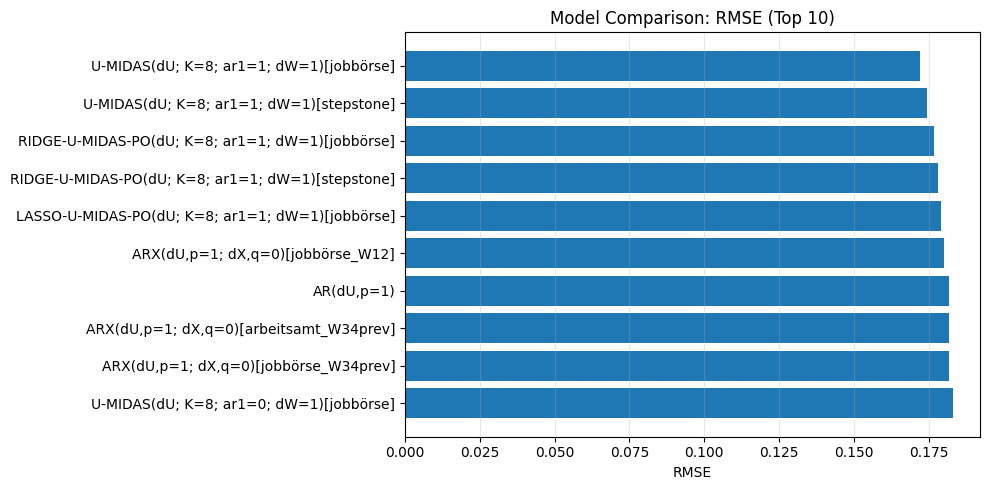

In [40]:
def plot_rmse_bar(leaderboard: pd.DataFrame, top_n: int = 10, title: str = None):
    top = leaderboard.head(top_n).iloc[::-1]
    plt.figure(figsize=(10, 5))
    plt.barh(top["model"], top["RMSE"])
    plt.xlabel("RMSE")
    plt.title(title or f"Model Comparison: RMSE (Top {top_n})")
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

plot_rmse_bar(leaderboard, top_n=10)


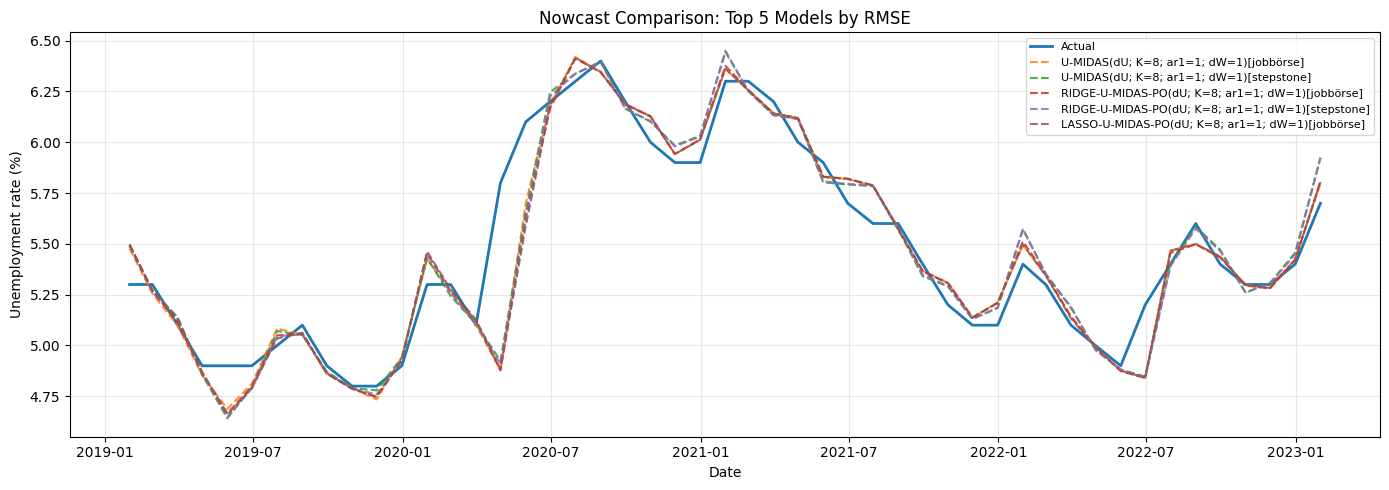

In [41]:
def plot_top_models(store: dict, leaderboard: pd.DataFrame, top_k: int = 5, title: str = None):
    top_models = leaderboard.head(top_k)["model"].tolist()
    base_act = store[top_models[0]]["act"]

    df = pd.DataFrame({"Actual": base_act})
    for m in top_models:
        df[m] = store[m]["pred"].reindex(base_act.index)

    plt.figure(figsize=(14, 5))
    plt.plot(df.index, df["Actual"], linewidth=2, label="Actual")
    for m in top_models:
        plt.plot(df.index, df[m], linestyle="--", label=m, alpha=0.85)
    plt.title(title or f"Nowcast Comparison: Top {top_k} Models by RMSE")
    plt.xlabel("Date"); plt.ylabel("Unemployment rate (%)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_top_models(store, leaderboard, top_k=5)

# plot the top models with especially with regard to MIDAS-ARX-AR

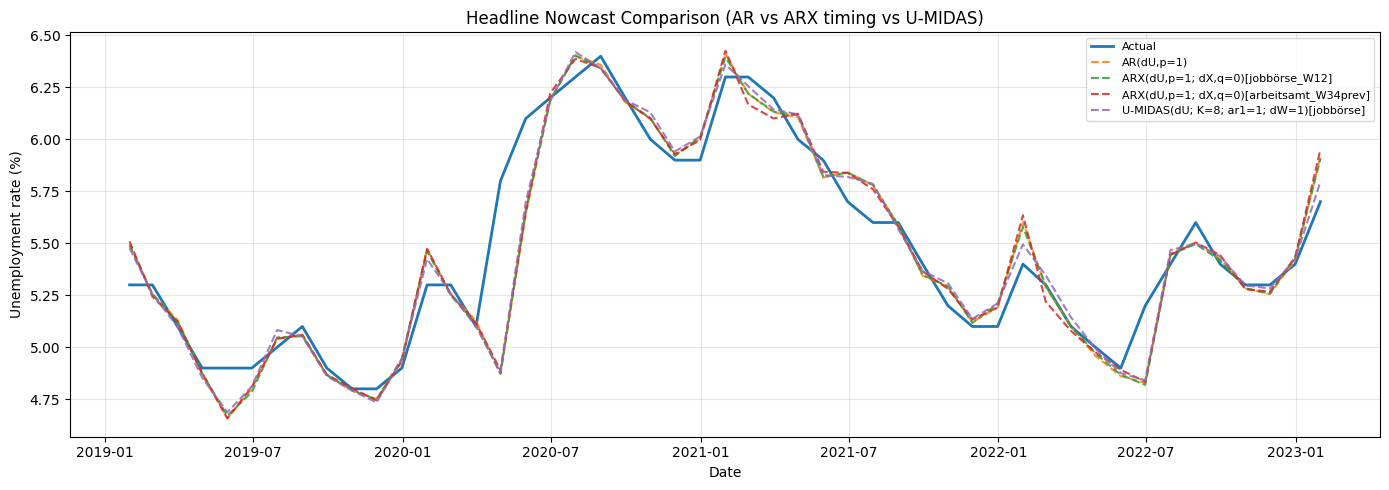

In [42]:
def plot_models(store: dict,
                leaderboard: pd.DataFrame = None,
                models: list = None,
                top_k: int = 5,
                title: str = None,
                include_actual: bool = True):
    """
    If models is provided, plot exactly those model predictions.
    Otherwise, plot top_k from leaderboard.
    """

    if models is None:
        if leaderboard is None:
            raise ValueError("Provide either `models` or `leaderboard`.")
        models = leaderboard.head(top_k)["model"].tolist()

    # Use act from the first listed model as the base index
    base_act = store[models[0]]["act"]
    df = pd.DataFrame(index=base_act.index)
    if include_actual:
        df["Actual"] = base_act

    for m in models:
        if m not in store:
            raise KeyError(f"Model '{m}' not found in store keys.")
        df[m] = store[m]["pred"].reindex(base_act.index)

    plt.figure(figsize=(14, 5))
    if include_actual:
        plt.plot(df.index, df["Actual"], linewidth=2, label="Actual")

    for m in models:
        plt.plot(df.index, df[m], linestyle="--", label=m, alpha=0.85)

    plt.title(title or "Nowcast Comparison")
    plt.xlabel("Date"); plt.ylabel("Unemployment rate (%)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


headline_models = [
    "AR(dU,p=1)",
    "ARX(dU,p=1; dX,q=0)[jobbörse_W12]",
    "ARX(dU,p=1; dX,q=0)[arbeitsamt_W34prev]",
    "U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse]"
]
plot_models(store, models=headline_models, title="Headline Nowcast Comparison (AR vs ARX timing vs U-MIDAS)")


# AR coefficients over time

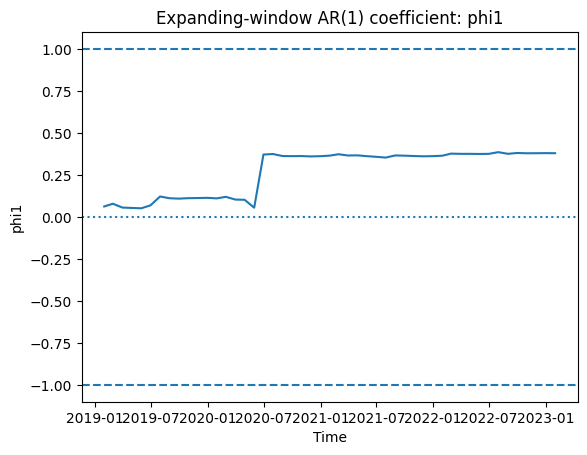

In [107]:
import matplotlib.pyplot as plt

phi_series = phi_series.sort_index()

plt.figure()
plt.plot(phi_series.index, phi_series.values)
plt.axhline(1.0, linestyle="--")
plt.axhline(-1.0, linestyle="--")
plt.axhline(0.0, linestyle=":")
plt.title("Expanding-window AR(1) coefficient: phi1")
plt.xlabel("Time")
plt.ylabel("phi1")
plt.show()


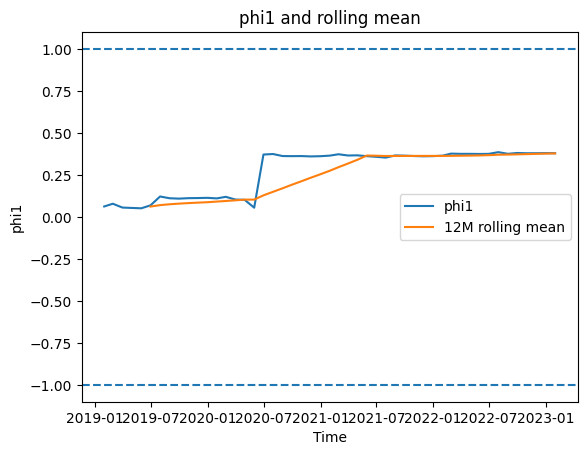

In [108]:
roll = phi_series.rolling(window=12, min_periods=6).mean()

plt.figure()
plt.plot(phi_series.index, phi_series.values, label="phi1")
plt.plot(roll.index, roll.values, label="12M rolling mean")
plt.axhline(1.0, linestyle="--")
plt.axhline(-1.0, linestyle="--")
plt.title("phi1 and rolling mean")
plt.xlabel("Time")
plt.ylabel("phi1")
plt.legend()
plt.show()


### Stability and Evolution of the AR(1) Benchmark

To assess the adequacy of the autoregressive benchmark estimated by OLS, the AR(1) coefficient in first differences is tracked across expanding estimation windows. The estimated coefficient remains comfortably inside the unit circle throughout the evaluation period, with values well below unity. This indicates that the short-run dynamics of monthly unemployment changes are stable and non-explosive.

The coefficient exhibits a smooth evolution over time rather than abrupt fluctuations. In particular, the degree of persistence increases around mid-2020 and subsequently stabilizes at a moderate level. This pattern is economically plausible and consistent with heightened persistence in labor market adjustments during and after the COVID-19 period, while not suggesting any loss of stability in the autoregressive structure.

Overall, these diagnostics support the use of a simple AR(1) model in first differences as a well-behaved and credible benchmark for the nowcasting exercise.


One mismatch to be aware of: selection uses full-sample dummies, estimation uses expanding-window dummies

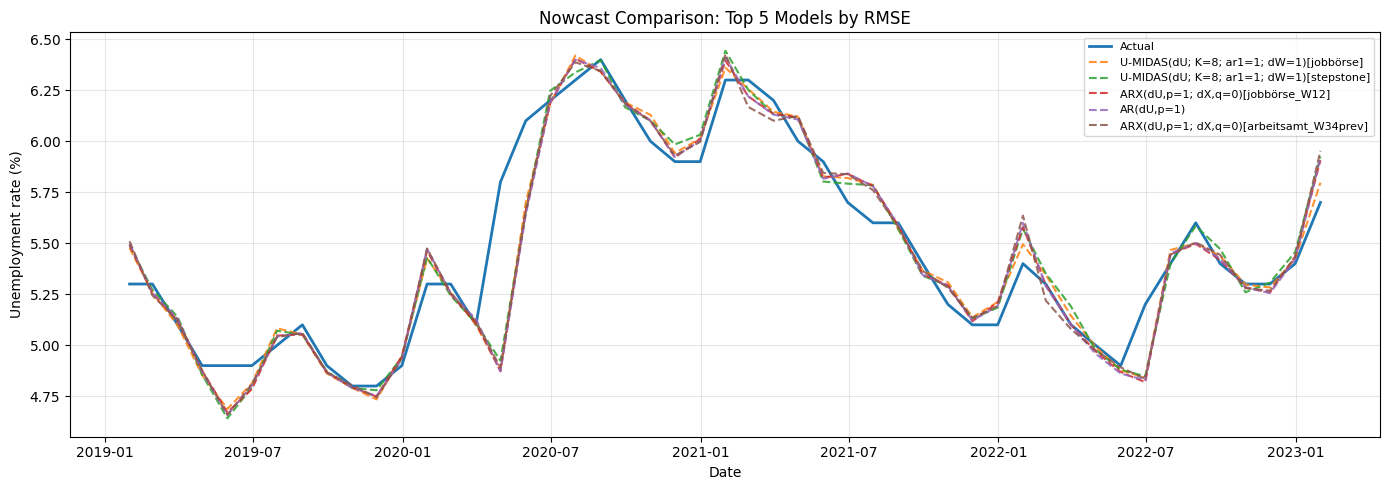

In [110]:
def plot_top_models(store: dict, leaderboard: pd.DataFrame, top_k: int = 5, title: str = None):
    top_models = leaderboard.head(top_k)["model"].tolist()
    base_act = store[top_models[0]]["act"]

    df = pd.DataFrame({"Actual": base_act})
    for m in top_models:
        df[m] = store[m]["pred"].reindex(base_act.index)

    plt.figure(figsize=(14, 5))
    plt.plot(df.index, df["Actual"], linewidth=2, label="Actual")
    for m in top_models:
        plt.plot(df.index, df[m], linestyle="--", label=m, alpha=0.85)
    plt.title(title or f"Nowcast Comparison: Top {top_k} Models by RMSE")
    plt.xlabel("Date"); plt.ylabel("Unemployment rate (%)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_top_models(store, leaderboard, top_k=5)

# Best ARX in W12 and W34 vs the true unemploymemnt

first I build a function to figure out which one


In [111]:
def best_arx_model(leaderboard, scheme: str) -> str:
    mask = (
        leaderboard["model"].str.contains("ARX", case=False) &
        leaderboard["model"].str.contains(scheme, case=False)
    )
    return leaderboard.loc[mask].iloc[0]["model"]

best_w12 = best_arx_model(leaderboard, "W12")
best_w34 = best_arx_model(leaderboard, "W34prev")

best_w12, best_w34

def common_support(store, models):
    idx = None
    for m in models:
        s = store[m]["pred"].dropna().index.intersection(
            store[m]["act"].dropna().index
        )
        idx = s if idx is None else idx.intersection(s)
    return idx


In [112]:
def plot_actual_vs_w12_w34(store, leaderboard, title=None):
    best_w12 = best_arx_model(leaderboard, "W12")
    best_w34 = best_arx_model(leaderboard, "W34prev")

    models = [best_w12, best_w34]
    idx = common_support(store, models)

    act = store[models[0]]["act"].reindex(idx)
    w12 = store[best_w12]["pred"].reindex(idx)
    w34 = store[best_w34]["pred"].reindex(idx)

    df = pd.DataFrame({
        "Actual": act,
        "ARX–W12": w12,
        "ARX–W34prev": w34
    }).dropna()

    plt.figure(figsize=(13,4))
    plt.plot(df.index, df["Actual"], linewidth=2.2, label="Actual")
    plt.plot(df.index, df["ARX–W12"], linestyle="--", label=f"Best ARX W12")
    plt.plot(df.index, df["ARX–W34prev"], linestyle=":", label=f"Best ARX W34prev")
    plt.xlabel("Date")
    plt.ylabel("Unemployment rate (%)")
    plt.title(title or "Actual unemployment vs best ARX nowcasts (W12 vs W34prev)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


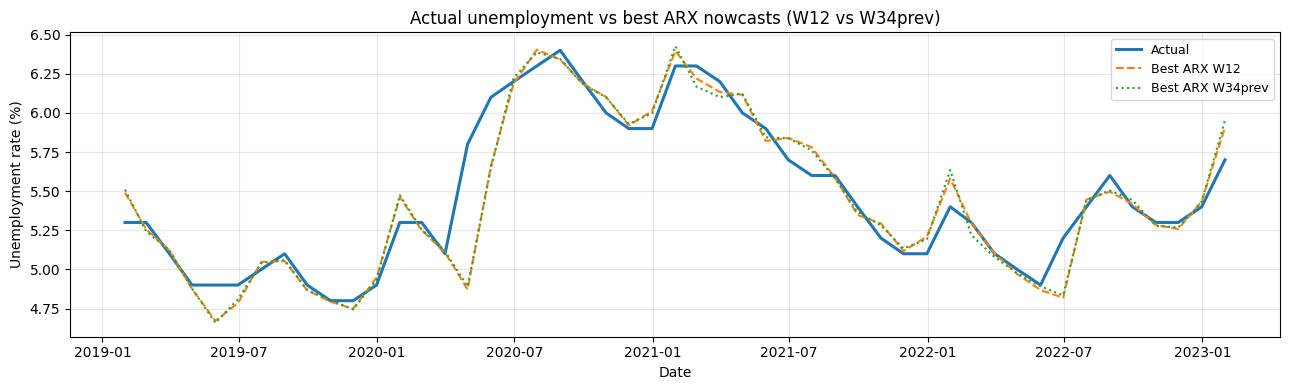

In [113]:
plot_actual_vs_w12_w34(store, leaderboard)


Comparing the absolute errors 

In [114]:
def plot_abs_error_w12_vs_w34(store, leaderboard, title=None):
    # identify best models
    best_w12 = best_arx_model(leaderboard, "W12")
    best_w34 = best_arx_model(leaderboard, "W34prev")

    models = [best_w12, best_w34]
    idx = common_support(store, models)

    # absolute errors on common support
    e_w12 = store[best_w12]["err"].reindex(idx).abs()
    e_w34 = store[best_w34]["err"].reindex(idx).abs()

    df = pd.DataFrame({
        "ARX–W12": e_w12,
        "ARX–W34prev": e_w34
    }).dropna()

    plt.figure(figsize=(13,4))
    plt.plot(df.index, df["ARX–W12"], linestyle="--", label="|Error| Best ARX W12")
    plt.plot(df.index, df["ARX–W34prev"], linestyle=":", label="|Error| Best ARX W34prev")
    plt.xlabel("Date")
    plt.ylabel("Absolute forecast error (pp)")
    plt.title(title or "Absolute forecast errors: Best ARX W12 vs W34prev")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


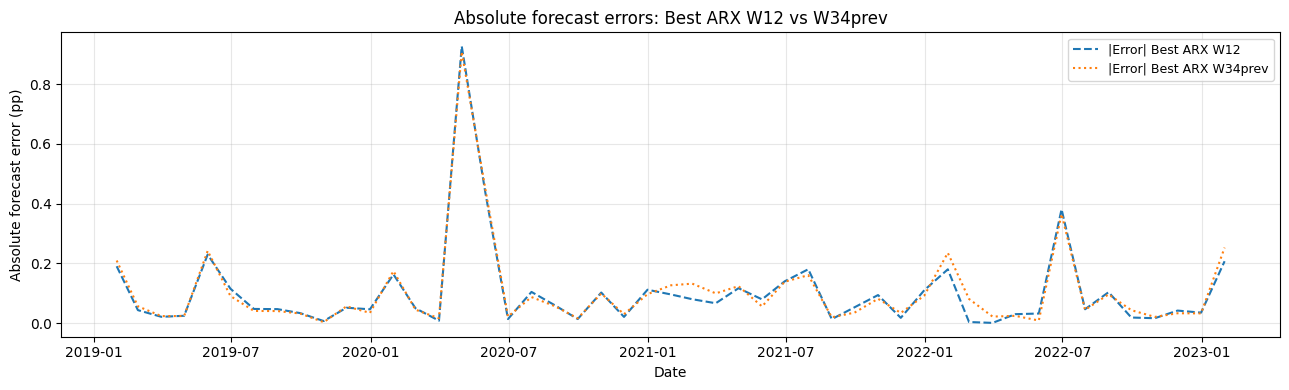

In [115]:
plot_abs_error_w12_vs_w34(store, leaderboard)


## Taken a look at the diagnostics


Model: U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse]
                pred  act       err   abs_err  month
2019-01-31  5.476531  5.3  0.176531  0.176531      1
2019-02-28  5.255997  5.3 -0.044003  0.044003      2
2019-03-31  5.097634  5.1 -0.002366  0.002366      3

Worst errors:
                pred  act       err   abs_err  month
2020-04-30  4.880084  5.8 -0.919916  0.919916      4
2020-05-31  5.698459  6.1 -0.401541  0.401541      5
2022-06-30  4.841206  5.2 -0.358794  0.358794      6
2019-05-31  4.687758  4.9 -0.212242  0.212242      5
2021-07-31  5.786148  5.6  0.186148  0.186148      7
2019-01-31  5.476531  5.3  0.176531  0.176531      1
2020-10-31  6.129180  6.0  0.129180  0.129180     10
2020-01-31  5.424652  5.3  0.124652  0.124652      1
2021-04-30  6.120267  6.0  0.120267  0.120267      4
2020-07-31  6.420128  6.3  0.120128  0.120128      7


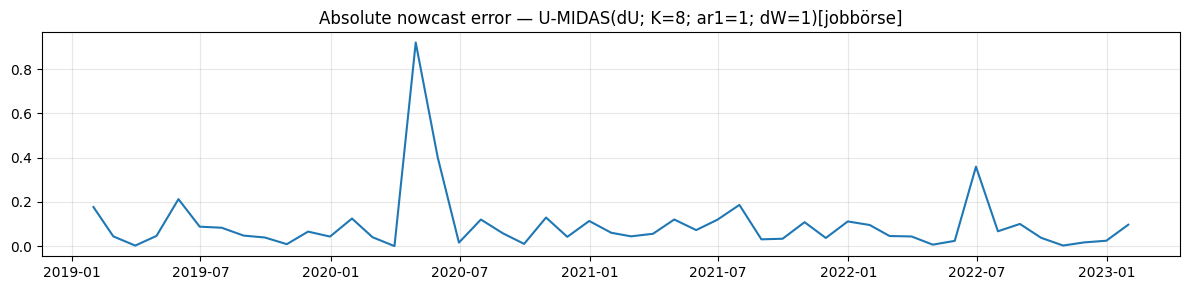


RMSE by month:
month
1     0.117283
2     0.043558
3     0.035431
4     0.464457
5     0.230265
6     0.194274
7     0.122954
8     0.064412
9     0.032129
10    0.084361
11    0.043858
12    0.083346
Name: err, dtype: float64


['ARX(dU,p=1; dX,q=0)[jobbörse_W12]',
 'ARX(dU,p=1; dX,q=0)[stepstone_W12]',
 'ARX(dU,p=1; dX,q=0)[bewerbung_W12]',
 'ARX(dU,p=1; dX,q=0)[arbeitsamt_W12]',
 'ARX(dU,p=1; dX,q=0)[indeed_W12]']

In [116]:
def diagnostics(model_name: str, store: dict, top_n: int = 10):
    pred = store[model_name]["pred"]
    act  = store[model_name]["act"]
    err  = store[model_name]["err"]

    df_eval = pd.concat([pred.rename("pred"), act.rename("act")], axis=1).dropna()
    df_eval["err"] = df_eval["pred"] - df_eval["act"]
    df_eval["abs_err"] = df_eval["err"].abs()
    df_eval["month"] = df_eval.index.month

    print(f"\nModel: {model_name}")
    print(df_eval.head(3))

    print("\nWorst errors:")
    print(df_eval.sort_values("abs_err", ascending=False).head(top_n))

    # abs error over time
    plt.figure(figsize=(12, 3))
    plt.plot(df_eval.index, df_eval["abs_err"])
    plt.title(f"Absolute nowcast error — {model_name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # RMSE by month
    rmse_by_month = df_eval.groupby("month")["err"].apply(lambda x: float(np.sqrt(np.mean(x**2))))
    print("\nRMSE by month:")
    print(rmse_by_month)

# Example: best model
best_model = leaderboard.loc[0, "model"]
diagnostics(best_model, store)


def list_models(leaderboard, contains: str = ""):
    s = leaderboard["model"]
    if contains:
        s = s[s.str.contains(contains, case=False, regex=False)]
    return s.tolist()

list_models(leaderboard, contains="W12")[:10]


## Diagnostics for the best models

In [117]:
top_models = leaderboard.head(3)["model"].tolist()



Model: U-MIDAS(dU; K=8; ar1=1; dW=1)[jobbörse]
                pred  act       err   abs_err  month
2019-01-31  5.476531  5.3  0.176531  0.176531      1
2019-02-28  5.255997  5.3 -0.044003  0.044003      2
2019-03-31  5.097634  5.1 -0.002366  0.002366      3

Worst errors:
                pred  act       err   abs_err  month
2020-04-30  4.880084  5.8 -0.919916  0.919916      4
2020-05-31  5.698459  6.1 -0.401541  0.401541      5
2022-06-30  4.841206  5.2 -0.358794  0.358794      6
2019-05-31  4.687758  4.9 -0.212242  0.212242      5
2021-07-31  5.786148  5.6  0.186148  0.186148      7
2019-01-31  5.476531  5.3  0.176531  0.176531      1
2020-10-31  6.129180  6.0  0.129180  0.129180     10
2020-01-31  5.424652  5.3  0.124652  0.124652      1
2021-04-30  6.120267  6.0  0.120267  0.120267      4
2020-07-31  6.420128  6.3  0.120128  0.120128      7


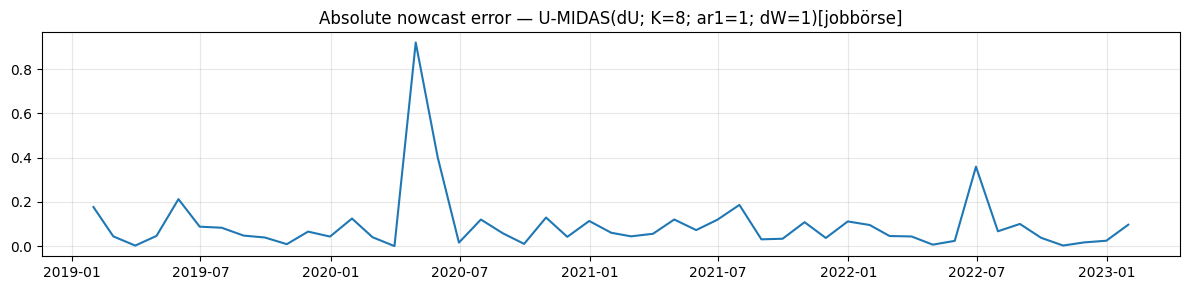


RMSE by month:
month
1     0.117283
2     0.043558
3     0.035431
4     0.464457
5     0.230265
6     0.194274
7     0.122954
8     0.064412
9     0.032129
10    0.084361
11    0.043858
12    0.083346
Name: err, dtype: float64

Model: U-MIDAS(dU; K=8; ar1=1; dW=1)[stepstone]
                pred  act       err   abs_err  month
2019-01-31  5.490588  5.3  0.190588  0.190588      1
2019-02-28  5.271769  5.3 -0.028231  0.028231      2
2019-03-31  5.138904  5.1  0.038904  0.038904      3

Worst errors:
                pred  act       err   abs_err  month
2020-04-30  4.924255  5.8 -0.875745  0.875745      4
2020-05-31  5.655788  6.1 -0.444212  0.444212      5
2022-06-30  4.847571  5.2 -0.352429  0.352429      6
2019-05-31  4.641585  4.9 -0.258415  0.258415      5
2023-01-31  5.924051  5.7  0.224051  0.224051      1
2019-01-31  5.490588  5.3  0.190588  0.190588      1
2021-07-31  5.783805  5.6  0.183805  0.183805      7
2022-01-31  5.570909  5.4  0.170909  0.170909      1
2021-01-31  6.44369

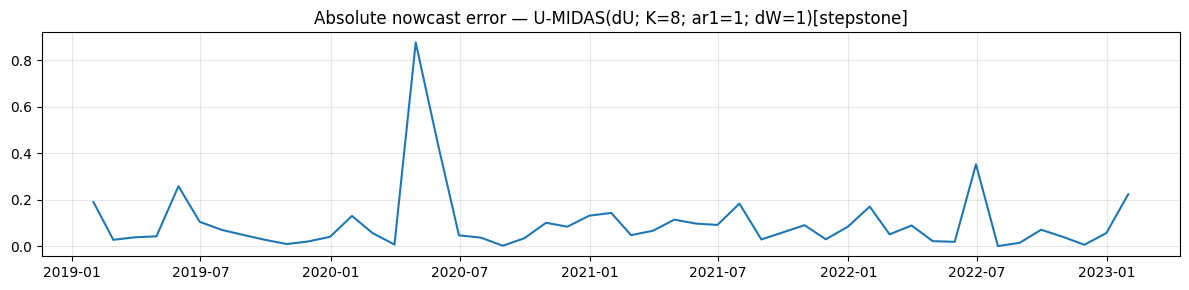


RMSE by month:
month
1     0.175197
2     0.047491
3     0.059382
4     0.442282
5     0.261730
6     0.191061
7     0.100259
8     0.029552
9     0.051524
10    0.071163
11    0.046158
12    0.085629
Name: err, dtype: float64

Model: ARX(dU,p=1; dX,q=0)[jobbörse_W12]
                pred  act       err   abs_err  month
2019-01-31  5.490304  5.3  0.190304  0.190304      1
2019-02-28  5.256830  5.3 -0.043170  0.043170      2
2019-03-31  5.120757  5.1  0.020757  0.020757      3

Worst errors:
                pred  act       err   abs_err  month
2020-04-30  4.872271  5.8 -0.927729  0.927729      4
2020-05-31  5.660620  6.1 -0.439380  0.439380      5
2022-06-30  4.818887  5.2 -0.381113  0.381113      6
2019-05-31  4.670514  4.9 -0.229486  0.229486      5
2023-01-31  5.907052  5.7  0.207052  0.207052      1
2019-01-31  5.490304  5.3  0.190304  0.190304      1
2021-07-31  5.780160  5.6  0.180160  0.180160      7
2022-01-31  5.579887  5.4  0.179887  0.179887      1
2020-01-31  5.462909  5.3 

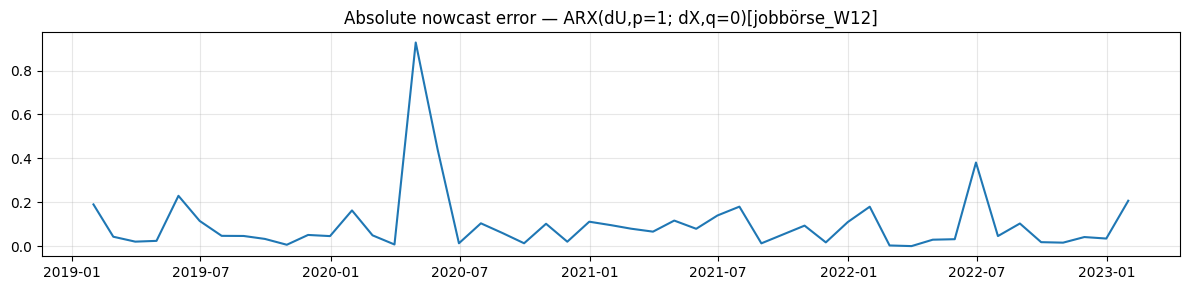


RMSE by month:
month
1     0.171548
2     0.051698
3     0.034954
4     0.467914
5     0.251506
6     0.211082
7     0.109180
8     0.064300
9     0.033162
10    0.069866
11    0.035663
12    0.083480
Name: err, dtype: float64

Model: AR(dU,p=1)
                pred  act       err   abs_err  month
2019-01-31  5.498222  5.3  0.198222  0.198222      1
2019-02-28  5.255729  5.3 -0.044271  0.044271      2
2019-03-31  5.130163  5.1  0.030163  0.030163      3

Worst errors:
                pred  act       err   abs_err  month
2020-04-30  4.872452  5.8 -0.927548  0.927548      4
2020-05-31  5.638385  6.1 -0.461615  0.461615      5
2022-06-30  4.828770  5.2 -0.371230  0.371230      6
2019-05-31  4.658608  4.9 -0.241392  0.241392      5
2023-01-31  5.918182  5.7  0.218182  0.218182      1
2022-01-31  5.599915  5.4  0.199915  0.199915      1
2019-01-31  5.498222  5.3  0.198222  0.198222      1
2021-07-31  5.779056  5.6  0.179056  0.179056      7
2020-01-31  5.472242  5.3  0.172242  0.172242    

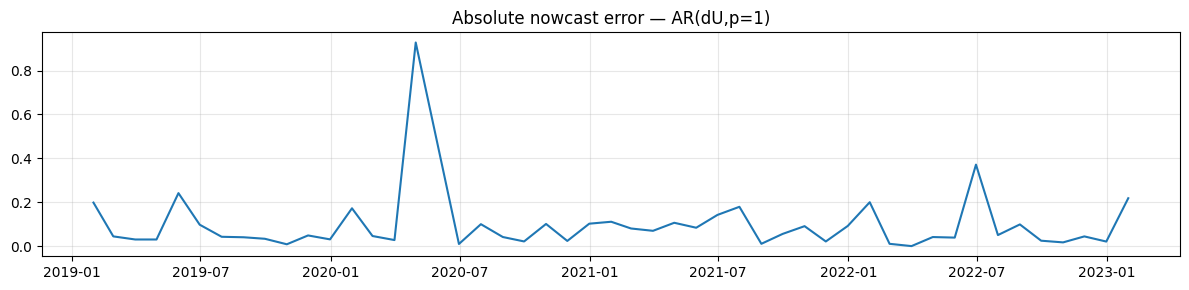


RMSE by month:
month
1     0.183761
2     0.051524
3     0.040380
4     0.467507
5     0.264511
6     0.204703
7     0.107674
8     0.057461
9     0.036258
10    0.068569
11    0.036457
12    0.071153
Name: err, dtype: float64

Model: ARX(dU,p=1; dX,q=0)[arbeitsamt_W34prev]
                pred  act       err   abs_err  month
2019-01-31  5.509451  5.3  0.209451  0.209451      1
2019-02-28  5.243912  5.3 -0.056088  0.056088      2
2019-03-31  5.123145  5.1  0.023145  0.023145      3

Worst errors:
                pred  act       err   abs_err  month
2020-04-30  4.890559  5.8 -0.909441  0.909441      4
2020-05-31  5.648686  6.1 -0.451314  0.451314      5
2022-06-30  4.834593  5.2 -0.365407  0.365407      6
2023-01-31  5.952675  5.7  0.252675  0.252675      1
2019-05-31  4.658192  4.9 -0.241808  0.241808      5
2022-01-31  5.635099  5.4  0.235099  0.235099      1
2019-01-31  5.509451  5.3  0.209451  0.209451      1
2020-01-31  5.474137  5.3  0.174137  0.174137      1
2021-07-31  5.760357

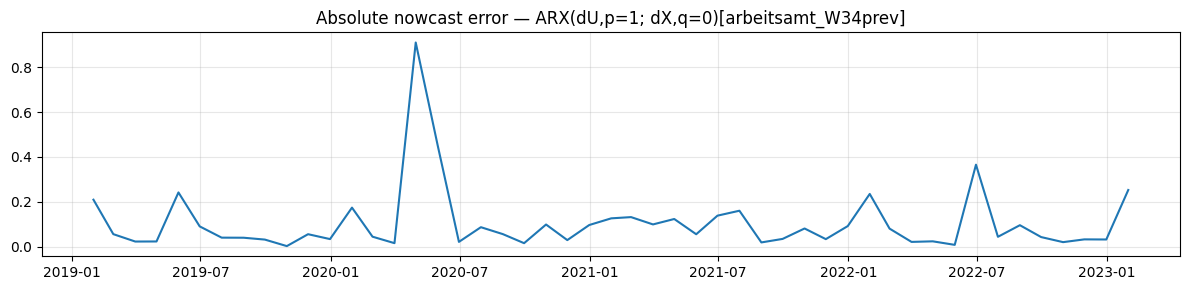


RMSE by month:
month
1     0.204594
2     0.085244
3     0.052751
4     0.459204
5     0.257546
6     0.200848
7     0.096026
8     0.059865
9     0.032910
10    0.064860
11    0.039398
12    0.070749
Name: err, dtype: float64


In [118]:
for m in leaderboard.head(5)["model"]:
    diagnostics(m, store)


## Comparison delta

In [119]:
def plot_delta_unemp(store: dict, models: list, title: str = None):
    # Choose a base actual series from the first model
    act = store[models[0]]["act"].dropna()
    dU_act = act.diff().rename("ΔUnemp_actual")

    df = pd.DataFrame({"ΔUnemp_actual": dU_act})
    for m in models:
        dU_pred = store[m]["pred"].reindex(act.index).diff().rename(f"ΔUnemp_{m}")
        df = df.join(dU_pred)

    df = df.dropna()

    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df["ΔUnemp_actual"], label="ΔUnemployment (actual)", linewidth=2)
    for m in models:
        plt.plot(df.index, df[f"ΔUnemp_{m}"], linestyle="--", alpha=0.9, label=f"ΔUnemp ({m})")
    plt.title(title or "Predicted vs actual monthly changes (ΔUnemployment)")
    plt.xlabel("Date"); plt.ylabel("Δ unemployment (pp)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


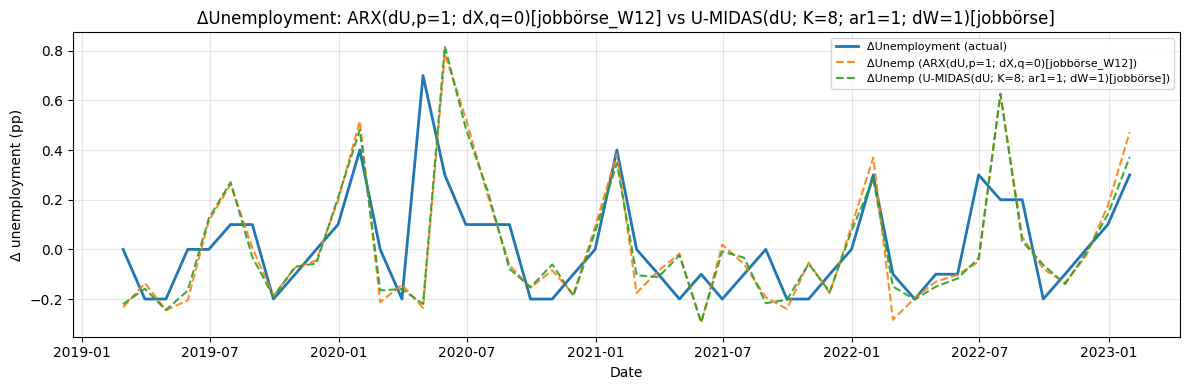

In [120]:
best_ar = leaderboard[leaderboard["model"].str.contains("^AR", regex=True)].iloc[0]["model"]
best_midas = leaderboard[leaderboard["model"].str.contains("UMIDAS|MIDAS", case=False, regex=True)].iloc[0]["model"]

plot_delta_unemp(
    store,
    models=[best_ar, best_midas],
    title=f"ΔUnemployment: {best_ar} vs {best_midas}"
)


## AR

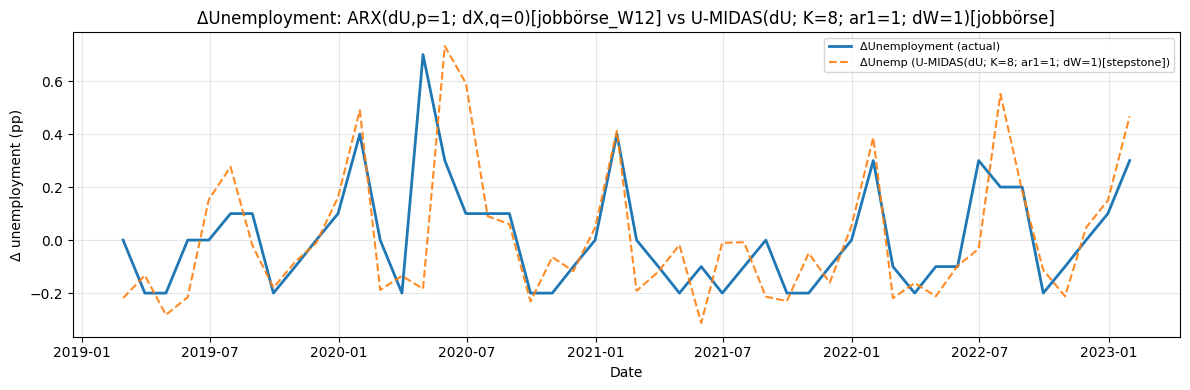

In [121]:
the_ar =  leaderboard[leaderboard["model"].str.contains("a", case=False, regex=True)].iloc[1]["model"]
plot_delta_unemp(
    store,
    models=[the_ar],
    title=f"ΔUnemployment: {best_ar} vs {best_midas}"
)


## Biweekly comparison

In [122]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _extract_scheme_and_keyword(model_name: str):
    """
    Works for model names like:
      - 'ARX(dU,p=2; dX,q=0)[jobbörse_W12]'
      - 'ARX(dU,p=2; dX,q=0)[jobbörse_W34prev]'
      - 'ARX_jobbörse_W12_...'
      - 'ARX_jobbörse_W34prev_...'
    Returns (keyword, scheme) or (None, None).
    """
    if "W12" in model_name:
        scheme = "W12"
    elif "W34prev" in model_name:
        scheme = "W34prev"
    else:
        return None, None

    # Try to grab the part inside brackets [...] first
    m = re.search(r"\[(.*?)\]", model_name)
    token = m.group(1) if m else model_name

    # Remove obvious prefixes
    token = token.replace("ARX_", "").replace("ARX(dU,p=2; dX,q=0)", "")

    # Remove scheme suffixes
    token = token.replace("_W12", "").replace("_W34prev", "")

    # Cleanup leftover characters
    token = re.sub(r"[^\wäöüÄÖÜß]+", "", token)

    keyword = token if token else None
    return keyword, scheme


def list_arx_biweekly_models(leaderboard: pd.DataFrame):
    s = leaderboard["model"].astype(str)
    return leaderboard[s.str.contains("ARX", case=False) & (s.str.contains("W12") | s.str.contains("W34prev"))].copy()


In [123]:
def summarize_w12_vs_w34(leaderboard: pd.DataFrame) -> pd.DataFrame:
    arx = list_arx_biweekly_models(leaderboard).copy()
    if arx.empty:
        raise ValueError("No ARX biweekly models found in leaderboard['model'].")

    arx["keyword"], arx["scheme"] = zip(*arx["model"].map(_extract_scheme_and_keyword))
    arx = arx.dropna(subset=["keyword", "scheme"])

    # pivot RMSE per keyword
    pivot = (arx.pivot_table(index="keyword", columns="scheme", values="RMSE", aggfunc="min")
               .sort_index())

    # add delta columns when both exist
    if "W12" in pivot.columns and "W34prev" in pivot.columns:
        pivot["ΔRMSE(W12−W34prev)"] = pivot["W12"] - pivot["W34prev"]
        pivot = pivot.sort_values("ΔRMSE(W12−W34prev)")
    return pivot

biweekly_rmse = summarize_w12_vs_w34(leaderboard)
biweekly_rmse


scheme,W12,W34prev,ΔRMSE(W12−W34prev)
keyword,,,
indeed,0.186145,0.192173,-0.006028
stepstone,0.183697,0.187925,-0.004228
jobbörse,0.180184,0.181839,-0.001655
bewerbung,0.183999,0.184673,-0.000674
arbeitsamt,0.184427,0.181729,0.002698


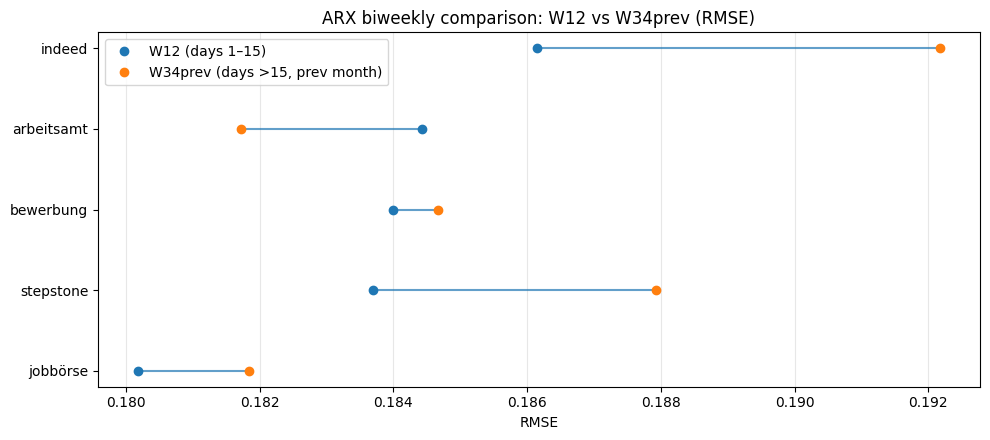

In [124]:
def plot_dumbbell_w12_w34(biweekly_rmse: pd.DataFrame, title: str = None):
    if not {"W12", "W34prev"}.issubset(biweekly_rmse.columns):
        raise ValueError("Need both W12 and W34prev columns in biweekly_rmse.")

    df = biweekly_rmse[["W12", "W34prev"]].dropna().copy()
    df = df.sort_values("W12")  # ordering choice; change if you want

    y = np.arange(len(df))
    plt.figure(figsize=(10, 0.5*len(df) + 2))
    plt.hlines(y=y, xmin=df["W12"], xmax=df["W34prev"], alpha=0.7)
    plt.plot(df["W12"], y, marker="o", linestyle="None", label="W12 (days 1–15)")
    plt.plot(df["W34prev"], y, marker="o", linestyle="None", label="W34prev (days >15, prev month)")

    plt.yticks(y, df.index)
    plt.xlabel("RMSE")
    plt.title(title or "ARX biweekly comparison: W12 vs W34prev (RMSE)")
    plt.grid(True, alpha=0.3, axis="x")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_dumbbell_w12_w34(biweekly_rmse)


In [125]:
def map_keyword_to_models(leaderboard: pd.DataFrame) -> pd.DataFrame:
    arx = list_arx_biweekly_models(leaderboard).copy()
    arx["keyword"], arx["scheme"] = zip(*arx["model"].map(_extract_scheme_and_keyword))
    arx = arx.dropna(subset=["keyword", "scheme"])

    # pick the best (lowest RMSE) model per keyword×scheme
    arx = arx.sort_values("RMSE").drop_duplicates(["keyword", "scheme"], keep="first")

    wide = arx.pivot(index="keyword", columns="scheme", values="model")
    return wide

kw_models = map_keyword_to_models(leaderboard)
kw_models


scheme,W12,W34prev
keyword,,
arbeitsamt,"ARX(dU,p=1; dX,q=0)[arbeitsamt_W12]","ARX(dU,p=1; dX,q=0)[arbeitsamt_W34prev]"
bewerbung,"ARX(dU,p=1; dX,q=0)[bewerbung_W12]","ARX(dU,p=1; dX,q=0)[bewerbung_W34prev]"
indeed,"ARX(dU,p=1; dX,q=0)[indeed_W12]","ARX(dU,p=1; dX,q=0)[indeed_W34prev]"
jobbörse,"ARX(dU,p=1; dX,q=0)[jobbörse_W12]","ARX(dU,p=1; dX,q=0)[jobbörse_W34prev]"
stepstone,"ARX(dU,p=1; dX,q=0)[stepstone_W12]","ARX(dU,p=1; dX,q=0)[stepstone_W34prev]"


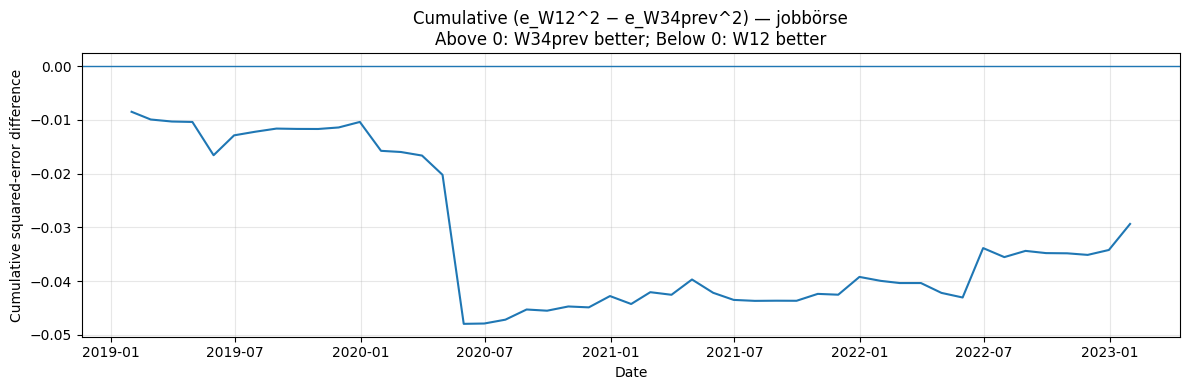

In [126]:
def plot_cum_sq_error_diff(keyword: str, store: dict, kw_models: pd.DataFrame):
    if keyword not in kw_models.index:
        raise ValueError(f"{keyword} not in kw_models.index")

    m12 = kw_models.loc[keyword].get("W12", None)
    m34 = kw_models.loc[keyword].get("W34prev", None)
    if pd.isna(m12) or pd.isna(m34):
        raise ValueError(f"Need both W12 and W34prev models for keyword={keyword}")

    e12 = store[m12]["err"].dropna()
    e34 = store[m34]["err"].dropna()
    idx = e12.index.intersection(e34.index)

    diff = (e12.loc[idx]**2 - e34.loc[idx]**2)  # >0 means W34prev better (lower loss)
    cum = diff.cumsum()

    plt.figure(figsize=(12,4))
    plt.plot(cum.index, cum.values)
    plt.axhline(0, linewidth=1)
    plt.title(f"Cumulative (e_W12^2 − e_W34prev^2) — {keyword}\nAbove 0: W34prev better; Below 0: W12 better")
    plt.xlabel("Date")
    plt.ylabel("Cumulative squared-error difference")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example:
plot_cum_sq_error_diff("jobbörse", store, kw_models)


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

def _hac_var(x: np.ndarray, L: int) -> float:
    """
    Newey–West HAC variance estimator for the sample mean of x.
    Returns Var(mean(x)) = (gamma0 + 2*sum_{l=1..L} w_l * gamma_l) / T
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    T = x.shape[0]
    if T <= 1:
        return np.nan

    gamma0 = np.dot(x, x) / T
    s = gamma0

    for l in range(1, L + 1):
        w = 1.0 - l / (L + 1.0)  # Bartlett weights
        gamma_l = np.dot(x[l:], x[:-l]) / T
        s += 2.0 * w * gamma_l

    return s / T  # variance of mean

def dm_test_paired(
    e1: pd.Series,
    e2: pd.Series,
    h: int = 1,
    loss: str = "mse",          # "mse" or "mae"
    hac_lags: int | None = None,
    small_sample: bool = True,
    alternative: str = "two-sided"  # "two-sided", "less", "greater"
) -> dict:
    """
    Diebold–Mariano test for equal predictive accuracy (paired forecasts).
    Compares model1 vs model2.

    d_t = L(e1_t) - L(e2_t)
    H0: E[d_t] = 0

    - If alternative="less":    E[d_t] < 0  -> model1 better (lower loss)
    - If alternative="greater": E[d_t] > 0  -> model2 better
    """
    # Align and drop missing
    df = pd.concat([e1.rename("e1"), e2.rename("e2")], axis=1).dropna()
    print(f"DM alignment: {len(e1.dropna())=} {len(e2.dropna())=} {df.shape[0]=}")

    if df.shape[0] < 10:
        return {"T": df.shape[0], "dm_stat": np.nan, "pvalue": np.nan, "mean_d": np.nan}

    if loss.lower() == "mse":
        d = df["e1"].to_numpy()**2 - df["e2"].to_numpy()**2
    elif loss.lower() == "mae":
        d = np.abs(df["e1"].to_numpy()) - np.abs(df["e2"].to_numpy())
    else:
        raise ValueError("loss must be 'mse' or 'mae'.")

    T = d.shape[0]

    # HAC lag choice: for h=1, serial corr is often small; but allow user control.
    if hac_lags is None:
        # common safe default: h-1 (for multi-step). For nowcasting h=1 => 0.
        L_rot = int(np.floor(4 * (T / 100.0) ** (2.0 / 9.0)))
        L = min(12, max(h - 1, L_rot))
    else:
        L = int(hac_lags)

    var_mean = _hac_var(d, L=L)
    if not np.isfinite(var_mean) or var_mean <= 0:
        return {"T": T, "dm_stat": np.nan, "pvalue": np.nan, "mean_d": float(np.mean(d))}

    dm = float(np.mean(d) / np.sqrt(var_mean))

    # Harvey–Leybourne–Newbold small-sample correction (widely used in applied work)
    if small_sample:
        # factor = sqrt((T + 1 - 2h + h(h-1)/T) / T)
        inside = (T + 1 - 2*h + (h*(h-1))/T) / T
        if inside > 0:
            dm *= float(np.sqrt(inside))
        else:
            pass

    # p-value using t distribution with T-1 df (common choice)
    dfree = T - 1
    if alternative == "two-sided":
        p = 2.0 * (1.0 - stats.t.cdf(abs(dm), df=dfree))
    elif alternative == "less":
        p = stats.t.cdf(dm, df=dfree)
    elif alternative == "greater":
        p = 1.0 - stats.t.cdf(dm, df=dfree)
    else:
        raise ValueError("alternative must be 'two-sided', 'less', or 'greater'.")

    return {
        "T": int(T),
        "mean_d": float(np.mean(d)),   # negative => model1 lower loss
        "dm_stat": float(dm),
        "pvalue": float(p),
        "hac_lags": int(L),
        "loss": loss.lower(),
        "h": int(h)
    }

def dm_biweekly_all_keywords(
    store: dict,
    kw_models: pd.DataFrame,
    h: int = 1,
    loss: str = "mse",
    hac_lags: int | None = None,
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Runs paired DM test per keyword: W12 vs W34prev.
    Uses errors from `store[model_name]['err']`.
    """
    rows = []
    for keyword in kw_models.index:
        m12 = kw_models.loc[keyword].get("W12", None)
        m34 = kw_models.loc[keyword].get("W34prev", None)

        if pd.isna(m12) or pd.isna(m34) or (m12 not in store) or (m34 not in store):
            continue

        e12 = store[m12]["err"]
        e34 = store[m34]["err"]

        res = dm_test_paired(
            e1=e12,
            e2=e34,
            h=h,
            loss=loss,
            hac_lags=hac_lags,
            small_sample=True,
            alternative="two-sided"
        )

        # Interpretation:
        # d = L(e_W12) - L(e_W34prev)
        # mean_d < 0 => W12 has LOWER average loss => W12 better
        if np.isfinite(res["mean_d"]):
            winner = "W12" if res["mean_d"] < 0 else "W34prev"
        else:
            winner = None

        rows.append({
            "keyword": keyword,
            "model_W12": m12,
            "model_W34prev": m34,
            **res,
            "winner_by_mean_loss": winner,
            "reject_equal_accuracy": bool(np.isfinite(res["pvalue"]) and (res["pvalue"] < alpha))
        })

    out = pd.DataFrame(rows).sort_values(["pvalue", "keyword"]).reset_index(drop=True)
    return out

# ---- RUN: DM tests for all keywords ----
dm_results_mse = dm_biweekly_all_keywords(
    store=store,
    kw_models=kw_models,
    h=1,
    loss="mse",
    hac_lags=0,     # for nowcasting (h=1) this is a reasonable default
    alpha=0.05
)

dm_results_mse


,keyword,model_W12,model_W34prev,T,mean_d,dm_stat,pvalue,hac_lags,loss,h,winner_by_mean_loss,reject_equal_accuracy
0,stepstone,"ARX(dU,p=1; dX,q=0)[stepstone_W12]","ARX(dU,p=1; dX,q=0)[stepstone_W34prev]",49,-0.001571,-1.277886,0.207435,0,mse,1,W12,False
1,jobbörse,"ARX(dU,p=1; dX,q=0)[jobbörse_W12]","ARX(dU,p=1; dX,q=0)[jobbörse_W34prev]",49,-0.000599,-0.881728,0.382318,0,mse,1,W12,False
2,indeed,"ARX(dU,p=1; dX,q=0)[indeed_W12]","ARX(dU,p=1; dX,q=0)[indeed_W34prev]",49,-0.002281,-0.719484,0.475331,0,mse,1,W12,False
3,arbeitsamt,"ARX(dU,p=1; dX,q=0)[arbeitsamt_W12]","ARX(dU,p=1; dX,q=0)[arbeitsamt_W34prev]",49,0.000988,0.707774,0.482509,0,mse,1,W34prev,False
4,bewerbung,"ARX(dU,p=1; dX,q=0)[bewerbung_W12]","ARX(dU,p=1; dX,q=0)[bewerbung_W34prev]",49,-0.000248,-0.165009,0.869630,0,mse,1,W12,False


In [128]:
dm_results_mae = dm_biweekly_all_keywords(
    store=store,
    kw_models=kw_models,
    h=1,
    loss="mae",
    hac_lags=0,
    alpha=0.05
)

dm_results_mae


,keyword,model_W12,model_W34prev,T,mean_d,dm_stat,pvalue,hac_lags,loss,h,winner_by_mean_loss,reject_equal_accuracy
0,bewerbung,"ARX(dU,p=1; dX,q=0)[bewerbung_W12]","ARX(dU,p=1; dX,q=0)[bewerbung_W34prev]",49,-0.003746,-1.345631,0.184744,0,mae,1,W12,False
1,jobbörse,"ARX(dU,p=1; dX,q=0)[jobbörse_W12]","ARX(dU,p=1; dX,q=0)[jobbörse_W34prev]",49,-0.001416,-0.857834,0.395247,0,mae,1,W12,False
2,stepstone,"ARX(dU,p=1; dX,q=0)[stepstone_W12]","ARX(dU,p=1; dX,q=0)[stepstone_W34prev]",49,-0.002220,-0.743104,0.461041,0,mae,1,W12,False
3,arbeitsamt,"ARX(dU,p=1; dX,q=0)[arbeitsamt_W12]","ARX(dU,p=1; dX,q=0)[arbeitsamt_W34prev]",49,-0.001553,-0.506147,0.615070,0,mae,1,W12,False
4,indeed,"ARX(dU,p=1; dX,q=0)[indeed_W12]","ARX(dU,p=1; dX,q=0)[indeed_W34prev]",49,-0.000507,-0.114162,0.909586,0,mae,1,W12,False
